# 06 - Adversarial Robustness and XAI

Phase 6 produces **explainability for the headline final track** and keeps a **legacy PCA appendix** for adversarial diagnostics.

**Final track (headline, Phase 5 weighted blend seed 42):**
- Input: ModernBERT 768-d + 9 behavioral features (777-d raw tabular).
- XAI target: `phase5_xgb_raw` (50% of the blend) with SHAP global + LIME local cases.
- Case selection uses precomputed `phase5_weighted_blend` probabilities and validation-selected thresholds (balanced τ=0.30).

**Legacy appendix (PCA 400-d):**
- FGSM/PGD robustness in PCA space, SHAP/LIME on PCA components.
- Not claimed as robustness evidence for the final raw+sequence pipeline.

Runtime contract:

- Run this notebook in Google Colab only.
- Do not run adversarial evaluation, SHAP, LIME, training, or dataset processing locally.
- Use seeded subsets to respect the 12GB RAM constraint.


## How to run on Colab

1. Run notebooks 01-05 first and sync artifacts to Google Drive.
2. Confirm **final track** artifacts exist: `features_raw_*.npy`, `phase5_xgb_raw.joblib`, `phase5_weighted_blend_test_prob.npy`.
3. Confirm **legacy appendix** artifacts exist: PCA features, Phase 4 checkpoint, `final_ensemble_model.pkl`.
4. Run this notebook top-to-bottom.
5. If RAM is tight, reduce `SHAP_SUBSET_SIZE` or `LIME_BACKGROUND_SIZE`.
6. After syncing outputs back, run `$gsd-verify-work phase 6`.


In [ ]:
# try/except: khối xử lý ngoại lệ
try:
    # import google.colab  # type: ignore: import thư viện google
    import google.colab  # type: ignore
# except: xử lý ngoại lệ — except ImportError as exc:
except ImportError as exc:
    # raise RuntimeError(: ném lỗi và dừng cell
    raise RuntimeError(
        # "Run this notebook in Google Colab. Local execution is disabled by project polic...: thực thi lệnh Python
        "Run this notebook in Google Colab. Local execution is disabled by project policy."
    # ) from exc: thực thi lệnh Python
    ) from exc


In [ ]:
# from google.colab import drive: import thư viện google
from google.colab import drive

# drive.mount("/content/drive"): mount Google Drive trên Colab
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# import importlib: import thư viện importlib
import importlib
# import json: đọc/ghi JSON metadata
import json
# import os: biến môi trường hệ thống
import os
# import platform: import thư viện platform
import platform
# import random: cố định seed ngẫu nhiên
import random
# import subprocess: chạy lệnh pip/cài package
import subprocess
# import sys: tham số Python runtime
import sys
# from datetime import datetime, timezone: import thư viện datetime
from datetime import datetime, timezone
# from pathlib import Path: quản lý đường dẫn
from pathlib import Path
# from typing import Any: import thư viện typing
from typing import Any


# ensure_package: import hoặc pip install package
def ensure_package(import_name: str, pip_name: str | None = None):
    # try/except: khối xử lý ngoại lệ
    try:
        # return: trả kết quả từ hàm
        return importlib.import_module(import_name)
    # except: xử lý ngoại lệ — except ImportError:
    except ImportError:
        # subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or impor...: thực thi lệnh Python
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or import_name])
        # return: trả kết quả từ hàm
        return importlib.import_module(import_name)


# joblib = ...: gán giá trị cho biến joblib
joblib = ensure_package("joblib")
# shap = ...: gán giá trị cho biến shap
shap = ensure_package("shap")
# lime_tabular = ...: gán giá trị cho biến lime tabular
lime_tabular = ensure_package("lime.lime_tabular", "lime")
# xgboost = ...: gán giá trị cho biến xgboost
xgboost = ensure_package("xgboost")
# lightgbm = ...: gán giá trị cho biến lightgbm
lightgbm = ensure_package("lightgbm")

# import matplotlib.pyplot: vẽ biểu đồ
import matplotlib.pyplot as plt
# import numpy: tính toán mảng số
import numpy as np
# import pandas: xử lý DataFrame
import pandas as pd
# import torch: deep learning PyTorch
import torch
# import torch.nn as nn: deep learning PyTorch
import torch.nn as nn
# import torch.nn.functional as F: deep learning PyTorch
import torch.nn.functional as F
# from sklearn.metrics import (: thư viện machine learning scikit-learn
from sklearn.metrics import (
    # accuracy_score,: thực thi lệnh Python
    accuracy_score,
    # average_precision_score,: thực thi lệnh Python
    average_precision_score,
    # confusion_matrix,: thực thi lệnh Python
    confusion_matrix,
    # f1_score,: thực thi lệnh Python
    f1_score,
    # precision_recall_fscore_support,: thực thi lệnh Python
    precision_recall_fscore_support,
    # roc_auc_score,: thực thi lệnh Python
    roc_auc_score,
# ): đóng ngoặc gọi hàm
)
# from sklearn.model_selection import StratifiedShuffleSplit: thư viện machine learning scikit-learn
from sklearn.model_selection import StratifiedShuffleSplit

# print("Python:", sys.version): in thông tin ra console
print("Python:", sys.version)
# print("Platform:", platform.platform()): in thông tin ra console
print("Platform:", platform.platform())
# print("Torch:", torch.__version__): in thông tin ra console
print("Torch:", torch.__version__)
# print("CUDA available:", torch.cuda.is_available()): in thông tin ra console
print("CUDA available:", torch.cuda.is_available())
# print("xgboost:", xgboost.__version__): in thông tin ra console
print("xgboost:", xgboost.__version__)
# print("lightgbm:", lightgbm.__version__): in thông tin ra console
print("lightgbm:", lightgbm.__version__)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Torch: 2.11.0+cu128
CUDA available: True
xgboost: 3.2.0
lightgbm: 4.6.0


In [ ]:
# SEED: biến cấu hình/hằng số của notebook
SEED = 42
# FAKE_LABEL: biến cấu hình/hằng số của notebook
FAKE_LABEL = 1
# REAL_LABEL: biến cấu hình/hằng số của notebook
REAL_LABEL = 0
# DEFAULT_THRESHOLD: biến cấu hình/hằng số của notebook
DEFAULT_THRESHOLD = 0.50
# MAX_BATCH_SIZE: biến cấu hình/hằng số của notebook
MAX_BATCH_SIZE = 64

# PROJECT_ROOT_CANDIDATES: biến cấu hình/hằng số của notebook
PROJECT_ROOT_CANDIDATES = [
    # Path(os.environ.get("FAKE_REVIEWS_PROJECT_ROOT", "")) if os.environ.get("FAKE_RE...: thực thi lệnh Python
    Path(os.environ.get("FAKE_REVIEWS_PROJECT_ROOT", "")) if os.environ.get("FAKE_REVIEWS_PROJECT_ROOT") else None,
    # Path("/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews"),: thực thi lệnh Python
    Path("/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews"),
    # Path("/content/drive/MyDrive/Fake_reviews"),: thực thi lệnh Python
    Path("/content/drive/MyDrive/Fake_reviews"),
# ]: đóng khối danh sách
]
# PROJECT_ROOT: biến cấu hình/hằng số của notebook
PROJECT_ROOT = next((path for path in PROJECT_ROOT_CANDIDATES if path is not None and path.exists()), None)
# if: điều kiện — if PROJECT_ROOT is None:
if PROJECT_ROOT is None:
    # candidates = ...: ép kiểu chuỗi
    candidates = [str(path) for path in PROJECT_ROOT_CANDIDATES if path is not None]
    # raise FileNotFoundError(f"Could not locate project root. Tried: {candidates}"): ném lỗi và dừng cell
    raise FileNotFoundError(f"Could not locate project root. Tried: {candidates}")

# PCA_DIR: biến cấu hình/hằng số của notebook
PCA_DIR = PROJECT_ROOT / "artifacts" / "pca"
# FEATURE_DIR: biến cấu hình/hằng số của notebook
FEATURE_DIR = PROJECT_ROOT / "artifacts" / "features"
# MODEL_DIR: biến cấu hình/hằng số của notebook
MODEL_DIR = PROJECT_ROOT / "artifacts" / "models"
# ENSEMBLE_DIR: biến cấu hình/hằng số của notebook
ENSEMBLE_DIR = PROJECT_ROOT / "artifacts" / "ensemble"
# XAI_DIR: biến cấu hình/hằng số của notebook
XAI_DIR = PROJECT_ROOT / "artifacts" / "xai"
# REPORT_TABLE_DIR: biến cấu hình/hằng số của notebook
REPORT_TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
# REPORT_FIGURE_DIR: biến cấu hình/hằng số của notebook
REPORT_FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

# for: vòng lặp — for directory in [XAI_DIR, REPORT_TABLE_DIR, REPORT_FIGURE_D
for directory in [XAI_DIR, REPORT_TABLE_DIR, REPORT_FIGURE_DIR]:
    # directory.mkdir(parents=True, exist_ok=True): tạo thư mục nếu chưa có
    directory.mkdir(parents=True, exist_ok=True)

# ROBUSTNESS_SUBSET_SIZE: biến cấu hình/hằng số của notebook
ROBUSTNESS_SUBSET_SIZE = 1000
# SHAP_SUBSET_SIZE: biến cấu hình/hằng số của notebook
SHAP_SUBSET_SIZE = 500
# LIME_BACKGROUND_SIZE: biến cấu hình/hằng số của notebook
LIME_BACKGROUND_SIZE = 1000
# LIME_NUM_CASES: biến cấu hình/hằng số của notebook
LIME_NUM_CASES = 6
# FGSM_EPSILONS: biến cấu hình/hằng số của notebook
FGSM_EPSILONS = [0.01, 0.03, 0.05]
# PGD_EPSILONS: biến cấu hình/hằng số của notebook
PGD_EPSILONS = [0.01, 0.03]
# PGD_STEPS: biến cấu hình/hằng số của notebook
PGD_STEPS = 5
# ADVERSARIAL_BATCH_SIZE: biến cấu hình/hằng số của notebook
ADVERSARIAL_BATCH_SIZE = 128
# PREDICT_BATCH_SIZE: biến cấu hình/hằng số của notebook
PREDICT_BATCH_SIZE = 64
# SHAP_MAX_DISPLAY: biến cấu hình/hằng số của notebook
SHAP_MAX_DISPLAY = 20
# LIME_NUM_FEATURES: biến cấu hình/hằng số của notebook
LIME_NUM_FEATURES = 12

# FEATURE_PATHS: biến cấu hình/hằng số của notebook
FEATURE_PATHS = {
    # "train": PCA_DIR / "features_final_train.npy",: thực thi lệnh Python
    "train": PCA_DIR / "features_final_train.npy",
    # "val": PCA_DIR / "features_final_val.npy",: thực thi lệnh Python
    "val": PCA_DIR / "features_final_val.npy",
    # "test": PCA_DIR / "features_final_test.npy",: thực thi lệnh Python
    "test": PCA_DIR / "features_final_test.npy",
# }: đóng khối từ điển
}
# LABEL_PATHS: biến cấu hình/hằng số của notebook
LABEL_PATHS = {
    # "train": PCA_DIR / "labels_train.npy",: thực thi lệnh Python
    "train": PCA_DIR / "labels_train.npy",
    # "val": PCA_DIR / "labels_val.npy",: thực thi lệnh Python
    "val": PCA_DIR / "labels_val.npy",
    # "test": PCA_DIR / "labels_test.npy",: thực thi lệnh Python
    "test": PCA_DIR / "labels_test.npy",
# }: đóng khối từ điển
}
# PHASE3_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE3_METADATA_PATH = PCA_DIR / "phase3_metadata.json"
# PCA_REDUCER_PATH: biến cấu hình/hằng số của notebook
PCA_REDUCER_PATH = PCA_DIR / "pca_or_svd.joblib"
# PHASE2_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE2_METADATA_PATH = FEATURE_DIR / "feature_metadata.json"
# FEATURE_DICTIONARY_PATH: biến cấu hình/hằng số của notebook
FEATURE_DICTIONARY_PATH = FEATURE_DIR / "feature_dictionary.csv"

# BEST_MODEL_PATH: biến cấu hình/hằng số của notebook
BEST_MODEL_PATH = MODEL_DIR / "best_model_dl.pth"
# BEST_PARAMS_PATH: biến cấu hình/hằng số của notebook
BEST_PARAMS_PATH = MODEL_DIR / "best_params.json"
# PHASE4_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE4_METADATA_PATH = MODEL_DIR / "phase4_metadata.json"

# XGBOOST_MODEL_PATH: biến cấu hình/hằng số của notebook
XGBOOST_MODEL_PATH = ENSEMBLE_DIR / "xgboost_model.pkl"
# LIGHTGBM_MODEL_PATH: biến cấu hình/hằng số của notebook
LIGHTGBM_MODEL_PATH = ENSEMBLE_DIR / "lightgbm_model.pkl"
# STACKING_META_MODEL_PATH: biến cấu hình/hằng số của notebook
STACKING_META_MODEL_PATH = ENSEMBLE_DIR / "stacking_meta_model.pkl"
# PROBABILITY_CALIBRATOR_PATH: biến cấu hình/hằng số của notebook
PROBABILITY_CALIBRATOR_PATH = ENSEMBLE_DIR / "probability_calibrator.pkl"
# FINAL_ENSEMBLE_MODEL_PATH: biến cấu hình/hằng số của notebook
FINAL_ENSEMBLE_MODEL_PATH = ENSEMBLE_DIR / "final_ensemble_model.pkl"
# PHASE5_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE5_METADATA_PATH = ENSEMBLE_DIR / "phase5_metadata.json"

# PHASE5_XGB_RAW_PATH: biến cấu hình/hằng số của notebook
PHASE5_XGB_RAW_PATH = ENSEMBLE_DIR / "phase5_xgb_raw.joblib"
# PHASE5_XGB_RAW_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE5_XGB_RAW_METADATA_PATH = ENSEMBLE_DIR / "phase5_xgb_raw_metadata.json"
# PHASE5_WEIGHTED_BLEND_METADATA_PATH: biến cấu hình/hằng số của notebook
PHASE5_WEIGHTED_BLEND_METADATA_PATH = ENSEMBLE_DIR / "phase5_weighted_blend_metadata.json"
# PREDICTIONS_DIR: biến cấu hình/hằng số của notebook
PREDICTIONS_DIR = PROJECT_ROOT / "artifacts" / "predictions"
# PHASE5_BLEND_TEST_PROB_PATH: biến cấu hình/hằng số của notebook
PHASE5_BLEND_TEST_PROB_PATH = PREDICTIONS_DIR / "phase5_weighted_blend_test_prob.npy"

# FINAL_RAW_FEATURE_PATHS: biến cấu hình/hằng số của notebook
FINAL_RAW_FEATURE_PATHS = {
    # "train": FEATURE_DIR / "features_raw_train.npy",: thực thi lệnh Python
    "train": FEATURE_DIR / "features_raw_train.npy",
    # "val": FEATURE_DIR / "features_raw_val.npy",: thực thi lệnh Python
    "val": FEATURE_DIR / "features_raw_val.npy",
    # "test": FEATURE_DIR / "features_raw_test.npy",: thực thi lệnh Python
    "test": FEATURE_DIR / "features_raw_test.npy",
# }: đóng khối từ điển
}
# FINAL_RAW_LABEL_PATHS: biến cấu hình/hằng số của notebook
FINAL_RAW_LABEL_PATHS = {
    # "train": FEATURE_DIR / "labels_train.npy",: thực thi lệnh Python
    "train": FEATURE_DIR / "labels_train.npy",
    # "val": FEATURE_DIR / "labels_val.npy",: thực thi lệnh Python
    "val": FEATURE_DIR / "labels_val.npy",
    # "test": FEATURE_DIR / "labels_test.npy",: thực thi lệnh Python
    "test": FEATURE_DIR / "labels_test.npy",
# }: đóng khối từ điển
}
# BALANCED_THRESHOLD: biến cấu hình/hằng số của notebook
BALANCED_THRESHOLD = 0.30
# PRECISION_FIRST_THRESHOLD: biến cấu hình/hằng số của notebook
PRECISION_FIRST_THRESHOLD = 0.60

# DEVICE: biến cấu hình/hằng số của notebook
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# PHASE6_FALLBACKS: list[dict[str, Any]] = []: chuyển/chiếu thành list
PHASE6_FALLBACKS: list[dict[str, Any]] = []


# seed_everything: cố định seed Python/numpy/torch
def seed_everything(seed: int = SEED) -> None:
    # random.seed(seed): cố định seed random
    random.seed(seed)
    # os.environ["PYTHONHASHSEED"] = str(seed): ép kiểu chuỗi
    os.environ["PYTHONHASHSEED"] = str(seed)
    # np.random.seed(seed): cố định seed numpy
    np.random.seed(seed)
    # torch.manual_seed(seed): cố định seed torch
    torch.manual_seed(seed)
    # if: điều kiện — if torch.cuda.is_available():
    if torch.cuda.is_available():
        # torch.cuda.manual_seed(seed): thực thi lệnh Python
        torch.cuda.manual_seed(seed)
        # torch.cuda.manual_seed_all(seed): thực thi lệnh Python
        torch.cuda.manual_seed_all(seed)
    # torch.backends.cudnn.deterministic = True: lấy giá trị nhỏ nhất
    torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False: thực thi lệnh Python
    torch.backends.cudnn.benchmark = False


# utc_now: định nghĩa hàm utc now
def utc_now() -> str:
    # return: trả kết quả từ hàm
    return datetime.now(timezone.utc).isoformat()


# read_json: đọc file JSON
def read_json(path: Path) -> dict[str, Any]:
    # with: context manager — with path.open("r", encoding="utf-8") as file:
    with path.open("r", encoding="utf-8") as file:
        # return: parse nội dung JSON
        return json.load(file)


# record_fallback: hàm xử lý record fallback
def record_fallback(kind: str, reason: str, decision: str) -> None:
    # PHASE6_FALLBACKS.append(: thực thi lệnh Python
    PHASE6_FALLBACKS.append(
        # {: thực thi lệnh Python
        {
            # "generated_at_utc": utc_now(),: thực thi lệnh Python
            "generated_at_utc": utc_now(),
            # "kind": kind,: thực thi lệnh Python
            "kind": kind,
            # "reason": reason,: thực thi lệnh Python
            "reason": reason,
            # "decision": decision,: thực thi lệnh Python
            "decision": decision,
        # }: đóng khối từ điển
        }
    # ): đóng ngoặc gọi hàm
    )


# stratified_subset_indices: hàm xử lý stratified subset indices
def stratified_subset_indices(labels: np.ndarray, subset_size: int, seed: int) -> np.ndarray:
    # labels = ...: ép kiểu dữ liệu cột
    labels = np.asarray(labels).astype(int)
    # if: điều kiện — if subset_size <= 0 or subset_size >= len(labels):
    if subset_size <= 0 or subset_size >= len(labels):
        # return: trả kết quả từ hàm
        return np.arange(len(labels), dtype=int)
    # splitter = ...: tạo tập hợp
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=int(subset_size), random_state=seed)
    # subset_idx, _ = next(splitter.split(np.zeros(len(labels)), labels)): đếm số phần tử
    subset_idx, _ = next(splitter.split(np.zeros(len(labels)), labels))
    # return: ép kiểu dữ liệu cột
    return np.sort(subset_idx.astype(int))


# positive_class_probability: hàm xử lý positive class probability
def positive_class_probability(model, X_array: np.ndarray) -> np.ndarray:
    # probabilities = ...: dự đoán nhãn/xác suất
    probabilities = np.asarray(model.predict_proba(X_array))
    # if: điều kiện — if probabilities.ndim == 1:
    if probabilities.ndim == 1:
        # return: ép kiểu dữ liệu cột
        return probabilities.astype(np.float32)
    # if: điều kiện — if probabilities.shape[1] == 1:
    if probabilities.shape[1] == 1:
        # return: ép kiểu dữ liệu cột
        return probabilities[:, 0].astype(np.float32)
    # return: ép kiểu dữ liệu cột
    return probabilities[:, FAKE_LABEL].astype(np.float32)


# to_two_column_prob: hàm xử lý to two column prob
def to_two_column_prob(prob_fake: np.ndarray) -> np.ndarray:
    # prob_fake = ...: ép kiểu số thực
    prob_fake = np.clip(np.asarray(prob_fake, dtype=np.float32), 0.0, 1.0)
    # return: ép kiểu dữ liệu cột
    return np.column_stack([1.0 - prob_fake, prob_fake]).astype(np.float32)


# choose_case: hàm xử lý choose case
def choose_case(indices: np.ndarray, probabilities: np.ndarray, prefer: str) -> int | None:
    # indices = ...: ép kiểu số nguyên
    indices = np.asarray(indices, dtype=int)
    # if: điều kiện — if len(indices) == 0:
    if len(indices) == 0:
        # return: trả kết quả từ hàm
        return None
    # if: điều kiện — if prefer == "highest_fake_probability":
    if prefer == "highest_fake_probability":
        # return: trả kết quả từ hàm
        return int(indices[np.argmax(probabilities[indices])])
    # if: điều kiện — if prefer == "lowest_fake_probability":
    if prefer == "lowest_fake_probability":
        # return: trả kết quả từ hàm
        return int(indices[np.argmin(probabilities[indices])])
    # return: trả kết quả từ hàm
    return int(indices[0])


# seed_everything(SEED): thực thi lệnh Python
seed_everything(SEED)
# print("Project root:", PROJECT_ROOT): in thông tin ra console
print("Project root:", PROJECT_ROOT)
# print("Device:", DEVICE): in thông tin ra console
print("Device:", DEVICE)
# if: điều kiện — if torch.cuda.is_available():
if torch.cuda.is_available():
    # print("GPU:", torch.cuda.get_device_name(0)): in thông tin ra console
    print("GPU:", torch.cuda.get_device_name(0))


Project root: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews
Device: cuda
GPU: Tesla T4


## 2. Final Track XAI (Headline Pipeline)

Explain the tabular half of the headline ensemble (`phase5_xgb_raw` on 777-d raw features). SHAP ranks BERT dimensions vs behavioral signals; LIME shows local decisions on representative test cases selected with `phase5_weighted_blend` probabilities at the balanced threshold τ=0.30.


In [ ]:
# build_raw_feature_names: hàm xử lý build raw feature names
def build_raw_feature_names(phase2_meta: dict[str, Any]) -> list[str]:
    # bert_dim = ...: ép kiểu số nguyên
    bert_dim = int(phase2_meta.get("bert", {}).get("embedding_dim", 768))
    # behavioral_names = ...: chuyển/chiếu thành list
    behavioral_names = list(phase2_meta.get("behavioral_features", {}).get("all", []))
    # return: trả kết quả từ hàm
    return [f"bert_{idx:03d}" for idx in range(bert_dim)] + behavioral_names


# final_required_paths = ...: gán giá trị cho biến final required paths
final_required_paths = [
    # PHASE2_METADATA_PATH,: thực thi lệnh Python
    PHASE2_METADATA_PATH,
    # PHASE5_XGB_RAW_PATH,: thực thi lệnh Python
    PHASE5_XGB_RAW_PATH,
    # PHASE5_BLEND_TEST_PROB_PATH,: thực thi lệnh Python
    PHASE5_BLEND_TEST_PROB_PATH,
    # PHASE5_METADATA_PATH,: thực thi lệnh Python
    PHASE5_METADATA_PATH,
    # *FINAL_RAW_FEATURE_PATHS.values(),: thực thi lệnh Python
    *FINAL_RAW_FEATURE_PATHS.values(),
    # *FINAL_RAW_LABEL_PATHS.values(),: thực thi lệnh Python
    *FINAL_RAW_LABEL_PATHS.values(),
# ]: đóng khối danh sách
]
# missing_final = ...: kiểm tra file/thư mục tồn tại
missing_final = [str(path) for path in final_required_paths if not path.exists()]
# if: điều kiện — if missing_final:
if missing_final:
    # raise FileNotFoundError("Missing required final-track XAI artifacts: " + json.du...: ghi dictionary ra JSON
    raise FileNotFoundError("Missing required final-track XAI artifacts: " + json.dumps(missing_final, indent=2))

# phase2_metadata_final = ...: đọc file JSON
phase2_metadata_final = read_json(PHASE2_METADATA_PATH)
# phase5_metadata_final = ...: đọc file JSON
phase5_metadata_final = read_json(PHASE5_METADATA_PATH)

# X_raw: dict[str, np.ndarray] = {}: tạo dictionary
X_raw: dict[str, np.ndarray] = {}
# y_raw: dict[str, np.ndarray] = {}: tạo dictionary
y_raw: dict[str, np.ndarray] = {}
# final_validation_rows = ...: gán giá trị cho biến final validation rows
final_validation_rows = []
# expected_raw_dim = ...: ép kiểu số nguyên
expected_raw_dim = int(phase2_metadata_final.get("fusion", {}).get("fused_dim", 777))

# for: vòng lặp — for split in ["train", "val", "test"]:
for split in ["train", "val", "test"]:
    # features = ...: nạp mảng từ file .npy
    features = np.load(FINAL_RAW_FEATURE_PATHS[split]).astype(np.float32, copy=False)
    # labels = ...: nạp mảng từ file .npy
    labels = np.load(FINAL_RAW_LABEL_PATHS[split]).astype(np.int64, copy=False)
    # if: điều kiện — if features.shape[0] != labels.shape[0]:
    if features.shape[0] != labels.shape[0]:
        # raise ValueError(f"final {split} row mismatch: features={features.shape[0]}, lab...: ném lỗi và dừng cell
        raise ValueError(f"final {split} row mismatch: features={features.shape[0]}, labels={labels.shape[0]}")
    # if: điều kiện — if expected_raw_dim and features.shape[1] != expected_raw_di
    if expected_raw_dim and features.shape[1] != expected_raw_dim:
        # raise ValueError(f"final {split} dim mismatch: {features.shape[1]} vs expected {...: ném lỗi và dừng cell
        raise ValueError(f"final {split} dim mismatch: {features.shape[1]} vs expected {expected_raw_dim}")
    # if: điều kiện — if not np.isfinite(features).all():
    if not np.isfinite(features).all():
        # raise ValueError(f"Non-finite raw feature values found in {split}"): ném lỗi và dừng cell
        raise ValueError(f"Non-finite raw feature values found in {split}")
    # X_raw[split] = features: thực thi lệnh Python
    X_raw[split] = features
    # y_raw[split] = labels: thực thi lệnh Python
    y_raw[split] = labels
    # final_validation_rows.append(: thực thi lệnh Python
    final_validation_rows.append(
        # {: thực thi lệnh Python
        {
            # "generated_at_utc": utc_now(),: thực thi lệnh Python
            "generated_at_utc": utc_now(),
            # "track": "final_raw_777",: thực thi lệnh Python
            "track": "final_raw_777",
            # "seed": SEED,: thực thi lệnh Python
            "seed": SEED,
            # "split": split,: thực thi lệnh Python
            "split": split,
            # "feature_path": str(FINAL_RAW_FEATURE_PATHS[split]),: ép kiểu chuỗi
            "feature_path": str(FINAL_RAW_FEATURE_PATHS[split]),
            # "label_path": str(FINAL_RAW_LABEL_PATHS[split]),: ép kiểu chuỗi
            "label_path": str(FINAL_RAW_LABEL_PATHS[split]),
            # "rows": int(features.shape[0]),: ép kiểu số nguyên
            "rows": int(features.shape[0]),
            # "feature_dim": int(features.shape[1]),: ép kiểu số nguyên
            "feature_dim": int(features.shape[1]),
            # "status": "pass",: thực thi lệnh Python
            "status": "pass",
        # }: đóng khối từ điển
        }
    # ): đóng ngoặc gọi hàm
    )

# RAW_INPUT_DIM: biến cấu hình/hằng số của notebook
RAW_INPUT_DIM = int(X_raw["train"].shape[1])
# raw_feature_names = ...: gán giá trị cho biến raw feature names
raw_feature_names = build_raw_feature_names(phase2_metadata_final)
# if: điều kiện — if len(raw_feature_names) != RAW_INPUT_DIM:
if len(raw_feature_names) != RAW_INPUT_DIM:
    # record_fallback("final_feature_names", f"name count {len(raw_feature_names)} != ...: đếm số phần tử
    record_fallback("final_feature_names", f"name count {len(raw_feature_names)} != dim {RAW_INPUT_DIM}", "use_index_names")
    # raw_feature_names = ...: tạo dãy số cho vòng lặp
    raw_feature_names = [f"raw_{idx:03d}" for idx in range(RAW_INPUT_DIM)]

# xgb_raw_model = ...: tải object đã lưu
xgb_raw_model = joblib.load(PHASE5_XGB_RAW_PATH)
# blend_test_prob = ...: nạp mảng từ file .npy
blend_test_prob = np.load(PHASE5_BLEND_TEST_PROB_PATH).astype(np.float32)
# if: điều kiện — if blend_test_prob.shape[0] != len(y_raw["test"]):
if blend_test_prob.shape[0] != len(y_raw["test"]):
    # raise ValueError(f"blend test prob rows {blend_test_prob.shape[0]} != test label...: ném lỗi và dừng cell
    raise ValueError(f"blend test prob rows {blend_test_prob.shape[0]} != test labels {len(y_raw['test'])}")

# balanced_threshold = ...: ép kiểu số thực
balanced_threshold = float(phase5_metadata_final.get("balanced_winner", {}).get("threshold", BALANCED_THRESHOLD))
# precision_first_threshold = ...: ép kiểu số thực
precision_first_threshold = float(phase5_metadata_final.get("precision_first_winner", {}).get("threshold", PRECISION_FIRST_THRESHOLD))
# final_lime_threshold = ...: gán giá trị cho biến final lime threshold
final_lime_threshold = balanced_threshold
# final_lime_threshold_strategy = ...: ép kiểu chuỗi
final_lime_threshold_strategy = "phase5_balanced_validation_threshold"

# predict_xgb_raw_fake_proba: hàm xử lý predict xgb raw fake proba
def predict_xgb_raw_fake_proba(model_obj, X_array: np.ndarray) -> np.ndarray:
    # return: trả kết quả từ hàm
    return positive_class_probability(model_obj, np.asarray(X_array, dtype=np.float32))

# predict_xgb_raw_proba: hàm xử lý predict xgb raw proba
def predict_xgb_raw_proba(model_obj, X_array: np.ndarray) -> np.ndarray:
    # return: dự đoán nhãn/xác suất
    return to_two_column_prob(predict_xgb_raw_fake_proba(model_obj, X_array))


# final_validation_path = ...: gán giá trị cho biến final validation path
final_validation_path = REPORT_TABLE_DIR / "phase6_final_input_validation.csv"
# pd.DataFrame(final_validation_rows).to_csv(final_validation_path, index=False): ghi DataFrame ra file CSV
pd.DataFrame(final_validation_rows).to_csv(final_validation_path, index=False)

# print("Validated final-track inputs. RAW_INPUT_DIM =", RAW_INPUT_DIM): in thông tin ra console
print("Validated final-track inputs. RAW_INPUT_DIM =", RAW_INPUT_DIM)
# print("XGB raw model:", PHASE5_XGB_RAW_PATH): in thông tin ra console
print("XGB raw model:", PHASE5_XGB_RAW_PATH)
# print("LIME/blend case threshold (balanced):", final_lime_threshold): in thông tin ra console
print("LIME/blend case threshold (balanced):", final_lime_threshold)
# display(pd.DataFrame(final_validation_rows)): hiển thị bảng/kết quả trên notebook
display(pd.DataFrame(final_validation_rows))


Validated final-track inputs. RAW_INPUT_DIM = 777
XGB raw model: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/ensemble/phase5_xgb_raw.joblib
LIME/blend case threshold (balanced): 0.3


,generated_at_utc,track,seed,split,feature_path,label_path,rows,feature_dim,status
0,2026-06-11T06:20:28.823906+00:00,final_raw_777,42,train,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,29923,777,pass
1,2026-06-11T06:20:28.855054+00:00,final_raw_777,42,val,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,6413,777,pass
2,2026-06-11T06:20:28.888660+00:00,final_raw_777,42,test,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,6413,777,pass


### 2.1 SHAP on `phase5_xgb_raw` (777-d tabular)

TreeExplainer on a stratified test subset. Behavioral features are directly interpretable; BERT dimensions are summarized as a block.


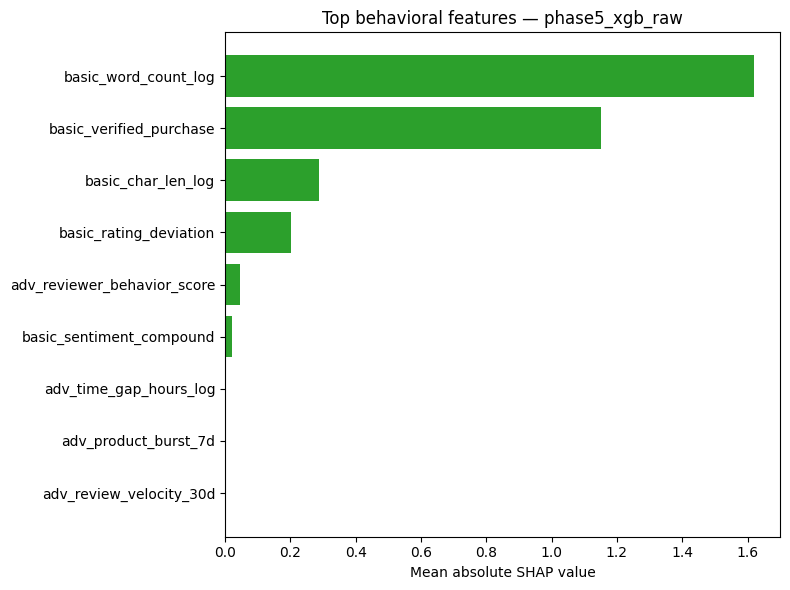

/tmp/ipykernel_1461/217688848.py:77: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


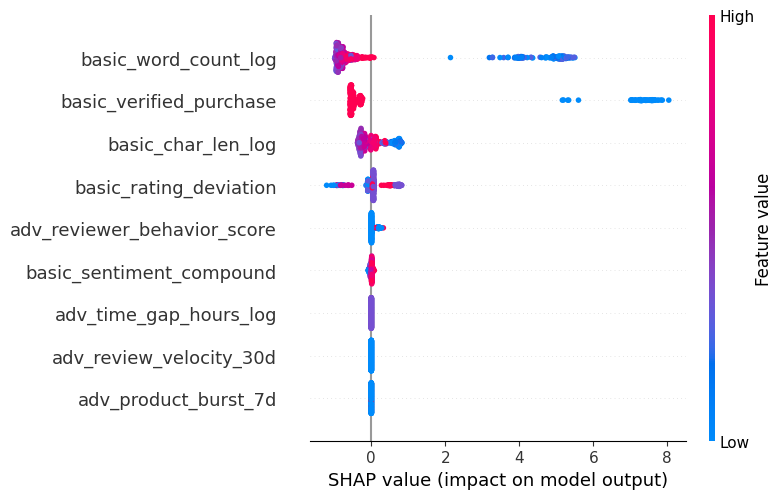

Saved final SHAP values: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/xai/phase6_final_shap_values_xgb.npy
Saved final SHAP importance: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase6_final_shap_global_importance.csv
Saved final SHAP block importance: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase6_final_shap_block_importance.csv


,generated_at_utc,seed,track,subset_name,subset_size,model_variant,feature_index,feature_name,feature_group,mean_abs_shap,rank
769,2026-06-11T06:19:04.659667+00:00,42,final_raw_777,test_stratified_shap,500,phase5_xgb_raw,769,basic_word_count_log,behavioral,1.618582,1
772,2026-06-11T06:19:04.659667+00:00,42,final_raw_777,test_stratified_shap,500,phase5_xgb_raw,772,basic_verified_purchase,behavioral,1.150413,2
768,2026-06-11T06:19:04.659667+00:00,42,final_raw_777,test_stratified_shap,500,phase5_xgb_raw,768,basic_char_len_log,behavioral,0.287488,3
770,2026-06-11T06:19:04.659667+00:00,42,final_raw_777,test_stratified_shap,500,phase5_xgb_raw,770,basic_rating_deviation,behavioral,0.202403,4
278,2026-06-11T06:19:04.659667+00:00,42,final_raw_777,test_stratified_shap,500,phase5_xgb_raw,278,bert_278,bert_embedding,0.128504,5
79,2026-06-11T06:19:04.659667+00:00,42,final_raw_777,test_stratified_shap,500,phase5_xgb_raw,79,bert_079,bert_embedding,0.100732,6
402,2026-06-11T06:19:04.659667+00:00,42,final_raw_777,test_stratified_shap,500,phase5_xgb_raw,402,bert_402,bert_embedding,0.075633,7
108,2026-06-11T06:19:04.659667+00:00,42,final_raw_777,test_stratified_shap,500,phase5_xgb_raw,108,bert_108,bert_embedding,0.074629,8
323,2026-06-11T06:19:04.659667+00:00,42,final_raw_777,test_stratified_shap,500,phase5_xgb_raw,323,bert_323,bert_embedding,0.069140,9
370,2026-06-11T06:19:04.659667+00:00,42,final_raw_777,test_stratified_shap,500,phase5_xgb_raw,370,bert_370,bert_embedding,0.067742,10


,generated_at_utc,seed,track,model_variant,feature_group,mean_abs_shap
1,2026-06-11T06:19:04.682114+00:00,42,final_raw_777,phase5_xgb_raw,bert_embedding,7.187336
0,2026-06-11T06:19:04.682114+00:00,42,final_raw_777,phase5_xgb_raw,behavioral,3.324986


In [ ]:
# final_shap_idx = ...: tạo tập hợp
final_shap_idx = stratified_subset_indices(y_raw["test"], SHAP_SUBSET_SIZE, SEED + 10)
# X_final_shap = ...: ép kiểu dữ liệu cột
X_final_shap = X_raw["test"][final_shap_idx].astype(np.float32, copy=True)
# final_shap_subset_path = ...: tạo tập hợp
final_shap_subset_path = REPORT_TABLE_DIR / "phase6_final_shap_subset_indices.csv"
# pd.DataFrame({"seed": SEED, "track": "final_raw_777", "split": "test", "row_inde...: ghi DataFrame ra file CSV
pd.DataFrame({"seed": SEED, "track": "final_raw_777", "split": "test", "row_index": final_shap_idx}).to_csv(final_shap_subset_path, index=False)

# final_explainer = ...: gán giá trị cho biến final explainer
final_explainer = shap.TreeExplainer(xgb_raw_model['model'])
# final_raw_shap = ...: gán giá trị cho biến final raw shap
final_raw_shap = final_explainer.shap_values(X_final_shap)
# if: điều kiện — if isinstance(final_raw_shap, list):
if isinstance(final_raw_shap, list):
    # final_shap_values_fake = ...: ép kiểu số thực
    final_shap_values_fake = np.asarray(final_raw_shap[FAKE_LABEL], dtype=np.float32)
# else: nhánh còn lại của điều kiện
else:
    # final_shap_array = ...: ép kiểu số thực
    final_shap_array = np.asarray(final_raw_shap, dtype=np.float32)
    # if: điều kiện — if final_shap_array.ndim == 3:
    if final_shap_array.ndim == 3:
        # final_shap_values_fake = ...: gán giá trị cho biến final shap values fake
        final_shap_values_fake = final_shap_array[:, :, FAKE_LABEL] if final_shap_array.shape[-1] > FAKE_LABEL else final_shap_array[:, :, 0]
    # else: nhánh còn lại của điều kiện
    else:
        # final_shap_values_fake = ...: gán giá trị cho biến final shap values fake
        final_shap_values_fake = final_shap_array
# if: điều kiện — if final_shap_values_fake.shape[1] != RAW_INPUT_DIM:
if final_shap_values_fake.shape[1] != RAW_INPUT_DIM:
    # raise ValueError(f"Final SHAP dim mismatch: {final_shap_values_fake.shape} vs RA...: ném lỗi và dừng cell
    raise ValueError(f"Final SHAP dim mismatch: {final_shap_values_fake.shape} vs RAW_INPUT_DIM={RAW_INPUT_DIM}")

# final_shap_values_path = ...: gán giá trị cho biến final shap values path
final_shap_values_path = XAI_DIR / "phase6_final_shap_values_xgb.npy"
# np.save(final_shap_values_path, final_shap_values_fake.astype(np.float32)): lưu mảng numpy ra file .npy
np.save(final_shap_values_path, final_shap_values_fake.astype(np.float32))
# final_shap_importance = ...: tính trung bình
final_shap_importance = np.abs(final_shap_values_fake).mean(axis=0)
# bert_dim = ...: ép kiểu số nguyên
bert_dim = int(phase2_metadata_final.get("bert", {}).get("embedding_dim", 768))
# behavioral_names = ...: chuyển/chiếu thành list
behavioral_names = list(phase2_metadata_final.get("behavioral_features", {}).get("all", []))
# feature_groups = ...: đếm số phần tử
feature_groups = ["bert_embedding"] * bert_dim + ["behavioral"] * len(behavioral_names)
# if: điều kiện — if len(feature_groups) != RAW_INPUT_DIM:
if len(feature_groups) != RAW_INPUT_DIM:
    # feature_groups = ...: gán giá trị cho biến feature groups
    feature_groups = ["unknown"] * RAW_INPUT_DIM

# final_shap_importance_df = ...: gán giá trị cho biến final shap importance df
final_shap_importance_df = pd.DataFrame(
    # {: thực thi lệnh Python
    {
        # "generated_at_utc": utc_now(),: thực thi lệnh Python
        "generated_at_utc": utc_now(),
        # "seed": SEED,: thực thi lệnh Python
        "seed": SEED,
        # "track": "final_raw_777",: thực thi lệnh Python
        "track": "final_raw_777",
        # "subset_name": "test_stratified_shap",: tạo tập hợp
        "subset_name": "test_stratified_shap",
        # "subset_size": len(final_shap_idx),: đếm số phần tử
        "subset_size": len(final_shap_idx),
        # "model_variant": "phase5_xgb_raw",: thực thi lệnh Python
        "model_variant": "phase5_xgb_raw",
        # "feature_index": np.arange(RAW_INPUT_DIM),: tạo dãy số cho vòng lặp
        "feature_index": np.arange(RAW_INPUT_DIM),
        # "feature_name": raw_feature_names,: thực thi lệnh Python
        "feature_name": raw_feature_names,
        # "feature_group": feature_groups,: thực thi lệnh Python
        "feature_group": feature_groups,
        # "mean_abs_shap": final_shap_importance,: tính trung bình
        "mean_abs_shap": final_shap_importance,
    # }: đóng khối từ điển
    }
# ).sort_values("mean_abs_shap", ascending=False): tính trung bình
).sort_values("mean_abs_shap", ascending=False)
# final_shap_importance_df["rank"] = np.arange(1, len(final_shap_importance_df) + ...: tạo dãy số cho vòng lặp
final_shap_importance_df["rank"] = np.arange(1, len(final_shap_importance_df) + 1)
# final_shap_importance_path = ...: gán giá trị cho biến final shap importance path
final_shap_importance_path = REPORT_TABLE_DIR / "phase6_final_shap_global_importance.csv"
# final_shap_importance_df.to_csv(final_shap_importance_path, index=False): ghi DataFrame ra file CSV
final_shap_importance_df.to_csv(final_shap_importance_path, index=False)

# final_block_importance_df = ...: gán giá trị cho biến final block importance df
final_block_importance_df = (
    # final_shap_importance_df.groupby("feature_group", as_index=False)["mean_abs_shap...: nhóm dữ liệu theo cột
    final_shap_importance_df.groupby("feature_group", as_index=False)["mean_abs_shap"]
    # .sum(): tính tổng
    .sum()
    # .sort_values("mean_abs_shap", ascending=False): tính trung bình
    .sort_values("mean_abs_shap", ascending=False)
# ): đóng ngoặc gọi hàm
)
# final_block_importance_df.insert(0, "generated_at_utc", utc_now()): thực thi lệnh Python
final_block_importance_df.insert(0, "generated_at_utc", utc_now())
# final_block_importance_df.insert(1, "seed", SEED): thực thi lệnh Python
final_block_importance_df.insert(1, "seed", SEED)
# final_block_importance_df.insert(2, "track", "final_raw_777"): thực thi lệnh Python
final_block_importance_df.insert(2, "track", "final_raw_777")
# final_block_importance_df.insert(3, "model_variant", "phase5_xgb_raw"): thực thi lệnh Python
final_block_importance_df.insert(3, "model_variant", "phase5_xgb_raw")
# final_block_importance_path = ...: gán giá trị cho biến final block importance path
final_block_importance_path = REPORT_TABLE_DIR / "phase6_final_shap_block_importance.csv"
# final_block_importance_df.to_csv(final_block_importance_path, index=False): ghi DataFrame ra file CSV
final_block_importance_df.to_csv(final_block_importance_path, index=False)

# top_behavioral = ...: xem vài dòng đầu
top_behavioral = final_shap_importance_df[final_shap_importance_df["feature_group"].eq("behavioral")].head(SHAP_MAX_DISPLAY)
# if: điều kiện — if not top_behavioral.empty:
if not top_behavioral.empty:
    # plot_df = ...: tính trung bình
    plot_df = top_behavioral.sort_values("mean_abs_shap")
    # plt.figure(figsize=(8, 6)): tạo figure matplotlib mới
    plt.figure(figsize=(8, 6))
    # plt.barh(plot_df["feature_name"], plot_df["mean_abs_shap"], color="tab:green"): vẽ biểu đồ cột
    plt.barh(plot_df["feature_name"], plot_df["mean_abs_shap"], color="tab:green")
    # plt.xlabel("Mean absolute SHAP value"): đặt nhãn trục X
    plt.xlabel("Mean absolute SHAP value")
    # plt.title("Top behavioral features — phase5_xgb_raw"): đặt tiêu đề biểu đồ
    plt.title("Top behavioral features — phase5_xgb_raw")
    # plt.tight_layout(): tự chỉnh lề biểu đồ
    plt.tight_layout()
    # final_shap_top_figure_path = ...: gán giá trị cho biến final shap top figure path
    final_shap_top_figure_path = REPORT_FIGURE_DIR / "phase6_final_shap_top_behavioral.png"
    # plt.savefig(final_shap_top_figure_path, dpi=160, bbox_inches="tight"): lưu biểu đồ ra file hình
    plt.savefig(final_shap_top_figure_path, dpi=160, bbox_inches="tight")
    # plt.show(): hiển thị biểu đồ
    plt.show()
# else: nhánh còn lại của điều kiện
else:
    # final_shap_top_figure_path = ...: gán giá trị cho biến final shap top figure path
    final_shap_top_figure_path = None
    # record_fallback("final_shap_plot", "no behavioral rows in SHAP table", "skip_beh...: thực thi lệnh Python
    record_fallback("final_shap_plot", "no behavioral rows in SHAP table", "skip_behavioral_bar")

# final_shap_summary_figure_path = ...: tính tổng
final_shap_summary_figure_path = REPORT_FIGURE_DIR / "phase6_final_shap_summary_behavioral.png"
# try/except: khối xử lý ngoại lệ
try:
    # behavioral_indices = ...: lặp kèm chỉ số
    behavioral_indices = [idx for idx, group in enumerate(feature_groups) if group == "behavioral"]
    # if: điều kiện — if behavioral_indices:
    if behavioral_indices:
        # shap.summary_plot(: tính tổng
        shap.summary_plot(
            # final_shap_values_fake[:, behavioral_indices],: thực thi lệnh Python
            final_shap_values_fake[:, behavioral_indices],
            # X_final_shap[:, behavioral_indices],: thực thi lệnh Python
            X_final_shap[:, behavioral_indices],
            # feature_names = ...: gán giá trị cho biến feature names
            feature_names=[raw_feature_names[idx] for idx in behavioral_indices],
            # max_display = ...: hiển thị bảng/kết quả trên notebook
            max_display=min(SHAP_MAX_DISPLAY, len(behavioral_indices)),
            # show = ...: gán giá trị cho biến show
            show=False,
        # ): đóng ngoặc gọi hàm
        )
        # plt.tight_layout(): tự chỉnh lề biểu đồ
        plt.tight_layout()
        # plt.savefig(final_shap_summary_figure_path, dpi=160, bbox_inches="tight"): lưu biểu đồ ra file hình
        plt.savefig(final_shap_summary_figure_path, dpi=160, bbox_inches="tight")
        # plt.show(): hiển thị biểu đồ
        plt.show()
    # else: nhánh còn lại của điều kiện
    else:
        # final_shap_summary_figure_path = ...: tính tổng
        final_shap_summary_figure_path = None
# except: xử lý ngoại lệ — except Exception as exc:
except Exception as exc:
    # record_fallback("final_shap_summary_plot", repr(exc), "saved_importance_tables_o...: tính tổng
    record_fallback("final_shap_summary_plot", repr(exc), "saved_importance_tables_only")
    # final_shap_summary_figure_path = ...: tính tổng
    final_shap_summary_figure_path = None

# print("Saved final SHAP values:", final_shap_values_path): in thông tin ra console
print("Saved final SHAP values:", final_shap_values_path)
# print("Saved final SHAP importance:", final_shap_importance_path): in thông tin ra console
print("Saved final SHAP importance:", final_shap_importance_path)
# print("Saved final SHAP block importance:", final_block_importance_path): in thông tin ra console
print("Saved final SHAP block importance:", final_block_importance_path)
# display(final_shap_importance_df.head(20)): hiển thị bảng/kết quả trên notebook
display(final_shap_importance_df.head(20))
# display(final_block_importance_df): hiển thị bảng/kết quả trên notebook
display(final_block_importance_df)


### 2.2 LIME on `phase5_xgb_raw` with blend-guided case selection

Representative FP/FN/TP cases are chosen using `phase5_weighted_blend` test probabilities at τ=0.30. Local explanations use the XGB raw tabular predictor on interpretable 777-d features.


In [ ]:
# select_final_lime_cases: hàm xử lý select final lime cases
def select_final_lime_cases(prob_fake: np.ndarray, labels: np.ndarray, threshold: float, threshold_strategy: str) -> pd.DataFrame:
    # pred = ...: ép kiểu dữ liệu cột
    pred = (prob_fake >= threshold).astype(int)
    # candidates = ...: gán giá trị cho biến candidates
    candidates = [
        # ("true_positive_fake", np.where((labels == FAKE_LABEL) & (pred == FAKE_LABEL))[0...: thực thi lệnh Python
        ("true_positive_fake", np.where((labels == FAKE_LABEL) & (pred == FAKE_LABEL))[0], "highest_fake_probability"),
        # ("true_negative_real", np.where((labels == REAL_LABEL) & (pred == REAL_LABEL))[0...: thực thi lệnh Python
        ("true_negative_real", np.where((labels == REAL_LABEL) & (pred == REAL_LABEL))[0], "lowest_fake_probability"),
        # ("false_positive_real_as_fake", np.where((labels == REAL_LABEL) & (pred == FAKE_...: thực thi lệnh Python
        ("false_positive_real_as_fake", np.where((labels == REAL_LABEL) & (pred == FAKE_LABEL))[0], "highest_fake_probability"),
        # ("false_negative_fake_as_real", np.where((labels == FAKE_LABEL) & (pred == REAL_...: thực thi lệnh Python
        ("false_negative_fake_as_real", np.where((labels == FAKE_LABEL) & (pred == REAL_LABEL))[0], "lowest_fake_probability"),
        # ("highest_confidence_fake_prediction", np.where(pred == FAKE_LABEL)[0], "highest...: dự đoán nhãn/xác suất
        ("highest_confidence_fake_prediction", np.where(pred == FAKE_LABEL)[0], "highest_fake_probability"),
        # ("highest_confidence_real_prediction", np.where(pred == REAL_LABEL)[0], "lowest_...: dự đoán nhãn/xác suất
        ("highest_confidence_real_prediction", np.where(pred == REAL_LABEL)[0], "lowest_fake_probability"),
    # ]: đóng khối danh sách
    ]
    # used = ...: tạo tập hợp
    used = set()
    # rows = ...: gán giá trị cho biến rows
    rows = []
    # for: vòng lặp — for case_type, candidate_idx, prefer in candidates:
    for case_type, candidate_idx, prefer in candidates:
        # available = ...: ép kiểu số nguyên
        available = np.asarray([idx for idx in candidate_idx if int(idx) not in used], dtype=int)
        # selected = ...: gán giá trị cho biến selected
        selected = choose_case(available, prob_fake, prefer)
        # if: điều kiện — if selected is None:
        if selected is None:
            # record_fallback("final_lime_case_selection", f"No available rows for {case_type}...: thực thi lệnh Python
            record_fallback("final_lime_case_selection", f"No available rows for {case_type}", "case_skipped")
            continue
        # used.add(int(selected)): ép kiểu số nguyên
        used.add(int(selected))
        # rows.append(: thực thi lệnh Python
        rows.append(
            # {: thực thi lệnh Python
            {
                # "case_type": case_type,: thực thi lệnh Python
                "case_type": case_type,
                # "test_row_index": int(selected),: ép kiểu số nguyên
                "test_row_index": int(selected),
                # "true_label": int(labels[selected]),: ép kiểu số nguyên
                "true_label": int(labels[selected]),
                # "predicted_label": int(pred[selected]),: dự đoán nhãn/xác suất
                "predicted_label": int(pred[selected]),
                # "probability_fake_blend": float(prob_fake[selected]),: ép kiểu số thực
                "probability_fake_blend": float(prob_fake[selected]),
                # "selected_threshold": float(threshold),: ép kiểu số thực
                "selected_threshold": float(threshold),
                # "threshold_strategy": threshold_strategy,: ép kiểu chuỗi
                "threshold_strategy": threshold_strategy,
                # "explained_model_variant": "phase5_xgb_raw",: thực thi lệnh Python
                "explained_model_variant": "phase5_xgb_raw",
            # }: đóng khối từ điển
            }
        # ): đóng ngoặc gọi hàm
        )
        # if: điều kiện — if len(rows) >= LIME_NUM_CASES:
        if len(rows) >= LIME_NUM_CASES:
            break
    # return: trả kết quả từ hàm
    return pd.DataFrame(rows)


# final_lime_background_idx = ...: làm tròn số
final_lime_background_idx = stratified_subset_indices(y_raw["train"], LIME_BACKGROUND_SIZE, SEED + 11)
# X_final_lime_background = ...: ép kiểu dữ liệu cột
X_final_lime_background = X_raw["train"][final_lime_background_idx].astype(np.float32, copy=True)
# final_lime_cases_df = ...: gán giá trị cho biến final lime cases df
final_lime_cases_df = select_final_lime_cases(
    # blend_test_prob,: đếm số phần tử
    blend_test_prob,
    # y_raw["test"],: thực thi lệnh Python
    y_raw["test"],
    # threshold = ...: gán giá trị cho biến threshold
    threshold=final_lime_threshold,
    # threshold_strategy = ...: ép kiểu chuỗi
    threshold_strategy=final_lime_threshold_strategy,
# ): đóng ngoặc gọi hàm
)
# if: điều kiện — if len(final_lime_cases_df) < 4:
if len(final_lime_cases_df) < 4:
    # record_fallback("final_lime_case_selection", f"Only {len(final_lime_cases_df)} r...: đếm số phần tử
    record_fallback("final_lime_case_selection", f"Only {len(final_lime_cases_df)} representative cases available", "continue_with_available_cases")

# final_lime_background_path = ...: làm tròn số
final_lime_background_path = REPORT_TABLE_DIR / "phase6_final_lime_background_indices.csv"
# pd.DataFrame({"seed": SEED, "track": "final_raw_777", "split": "train", "row_ind...: ghi DataFrame ra file CSV
pd.DataFrame({"seed": SEED, "track": "final_raw_777", "split": "train", "row_index": final_lime_background_idx}).to_csv(final_lime_background_path, index=False)

# final_lime_explainer = ...: gán giá trị cho biến final lime explainer
final_lime_explainer = lime_tabular.LimeTabularExplainer(
    # training_data = ...: làm tròn số
    training_data=X_final_lime_background,
    # feature_names = ...: gán giá trị cho biến feature names
    feature_names=raw_feature_names,
    # class_names = ...: gán giá trị cho biến class names
    class_names=["real", "fake"],
    # mode = ...: gán giá trị cho biến mode
    mode="classification",
    # discretize_continuous = ...: gán giá trị cho biến discretize continuous
    discretize_continuous=True,
    # random_state = ...: gán giá trị cho biến random state
    random_state=SEED,
# ): đóng ngoặc gọi hàm
)

# final_lime_weight_rows = ...: gán giá trị cho biến final lime weight rows
final_lime_weight_rows = []
# final_case_summary_rows = ...: tính tổng
final_case_summary_rows = []
# for: vòng lặp — for case_number, case in enumerate(final_lime_cases_df.to_di
for case_number, case in enumerate(final_lime_cases_df.to_dict(orient="records"), start=1):
    # row_index = ...: ép kiểu số nguyên
    row_index = int(case["test_row_index"])
    # explanation = ...: gán giá trị cho biến explanation
    explanation = final_lime_explainer.explain_instance(
        # X_raw["test"][row_index],: thực thi lệnh Python
        X_raw["test"][row_index],
        # lambda x: predict_xgb_raw_proba(xgb_raw_model['model'], x),: dự đoán nhãn/xác suất
        lambda x: predict_xgb_raw_proba(xgb_raw_model['model'], x), # Modified here
        # num_features = ...: gán giá trị cho biến num features
        num_features=LIME_NUM_FEATURES,
        # labels = ...: gán giá trị cho biến labels
        labels=[FAKE_LABEL],
    # ): đóng ngoặc gọi hàm
    )
    # safe_case_type = ...: ép kiểu chuỗi
    safe_case_type = str(case["case_type"]).replace("/", "_").replace(" ", "_")
    # html_path = ...: gán giá trị cho biến html path
    html_path = XAI_DIR / f"phase6_final_lime_case_{case_number:02d}_{safe_case_type}.html"
    # explanation.save_to_file(str(html_path)): ép kiểu chuỗi
    explanation.save_to_file(str(html_path))
    # xgb_prob = ...: dự đoán nhãn/xác suất
    xgb_prob = float(predict_xgb_raw_fake_proba(xgb_raw_model['model'], X_raw["test"][row_index : row_index + 1])[0]) # Modified here
    # final_case_summary_rows.append(: tính tổng
    final_case_summary_rows.append(
        # {: thực thi lệnh Python
        {
            # "generated_at_utc": utc_now(),: thực thi lệnh Python
            "generated_at_utc": utc_now(),
            # "seed": SEED,: thực thi lệnh Python
            "seed": SEED,
            # "track": "final_raw_777",: thực thi lệnh Python
            "track": "final_raw_777",
            # "case_number": case_number,: thực thi lệnh Python
            "case_number": case_number,
            # "case_type": case["case_type"],: thực thi lệnh Python
            "case_type": case["case_type"],
            # "split": "test",: thực thi lệnh Python
            "split": "test",
            # "test_row_index": row_index,: thực thi lệnh Python
            "test_row_index": row_index,
            # "true_label": int(case["true_label"]),: ép kiểu số nguyên
            "true_label": int(case["true_label"]),
            # "predicted_label_blend": int(case["predicted_label"]),: dự đoán nhãn/xác suất
            "predicted_label_blend": int(case["predicted_label"]),
            # "probability_fake_blend": float(case["probability_fake_blend"]),: ép kiểu số thực
            "probability_fake_blend": float(case["probability_fake_blend"]),
            # "probability_fake_xgb_raw": xgb_prob,: thực thi lệnh Python
            "probability_fake_xgb_raw": xgb_prob,
            # "selected_threshold": float(case["selected_threshold"]),: ép kiểu số thực
            "selected_threshold": float(case["selected_threshold"]),
            # "threshold_strategy": case["threshold_strategy"],: ép kiểu chuỗi
            "threshold_strategy": case["threshold_strategy"],
            # "explained_model_variant": case["explained_model_variant"],: thực thi lệnh Python
            "explained_model_variant": case["explained_model_variant"],
            # "lime_html_path": str(html_path),: ép kiểu chuỗi
            "lime_html_path": str(html_path),
        # }: đóng khối từ điển
        }
    # ): đóng ngoặc gọi hàm
    )
    # for: vòng lặp — for feature_rank, (feature_rule, weight) in enumerate(explan
    for feature_rank, (feature_rule, weight) in enumerate(explanation.as_list(label=FAKE_LABEL), start=1):
        # final_lime_weight_rows.append(: thực thi lệnh Python
        final_lime_weight_rows.append(
            # {: thực thi lệnh Python
            {
                # "generated_at_utc": utc_now(),: thực thi lệnh Python
                "generated_at_utc": utc_now(),
                # "seed": SEED,: thực thi lệnh Python
                "seed": SEED,
                # "track": "final_raw_777",: thực thi lệnh Python
                "track": "final_raw_777",
                # "case_number": case_number,: thực thi lệnh Python
                "case_number": case_number,
                # "case_type": case["case_type"],: thực thi lệnh Python
                "case_type": case["case_type"],
                # "test_row_index": row_index,: thực thi lệnh Python
                "test_row_index": row_index,
                # "feature_rank": feature_rank,: thực thi lệnh Python
                "feature_rank": feature_rank,
                # "lime_feature_rule": feature_rule,: thực thi lệnh Python
                "lime_feature_rule": feature_rule,
                # "lime_weight_for_fake": float(weight),: ép kiểu số thực
                "lime_weight_for_fake": float(weight),
                # "selected_threshold": float(final_lime_threshold),: ép kiểu số thực
                "selected_threshold": float(final_lime_threshold),
                # "model_variant": "phase5_xgb_raw",: thực thi lệnh Python
                "model_variant": "phase5_xgb_raw",
            # }: đóng khối từ điển
            }
        # ): đóng ngoặc gọi hàm
        )

# final_lime_case_summary_df = ...: tính tổng
final_lime_case_summary_df = pd.DataFrame(final_case_summary_rows)
# final_lime_feature_weights_df = ...: gán giá trị cho biến final lime feature weights df
final_lime_feature_weights_df = pd.DataFrame(final_lime_weight_rows)
# final_lime_case_summary_path = ...: tính tổng
final_lime_case_summary_path = REPORT_TABLE_DIR / "phase6_final_lime_case_summary.csv"
# final_lime_feature_weights_path = ...: gán giá trị cho biến final lime feature weights path
final_lime_feature_weights_path = REPORT_TABLE_DIR / "phase6_final_lime_feature_weights.csv"
# final_lime_case_summary_df.to_csv(final_lime_case_summary_path, index=False): ghi DataFrame ra file CSV
final_lime_case_summary_df.to_csv(final_lime_case_summary_path, index=False)
# final_lime_feature_weights_df.to_csv(final_lime_feature_weights_path, index=Fals...: ghi DataFrame ra file CSV
final_lime_feature_weights_df.to_csv(final_lime_feature_weights_path, index=False)
# display(final_lime_case_summary_df): hiển thị bảng/kết quả trên notebook
display(final_lime_case_summary_df)
# display(final_lime_feature_weights_df.head(30)): hiển thị bảng/kết quả trên notebook
display(final_lime_feature_weights_df.head(30))
# print("Saved final LIME case summary:", final_lime_case_summary_path): in thông tin ra console
print("Saved final LIME case summary:", final_lime_case_summary_path)
# print("Saved final LIME weights:", final_lime_feature_weights_path): in thông tin ra console
print("Saved final LIME weights:", final_lime_feature_weights_path)


## 3. Legacy Appendix — Validate PCA / Phase 3-5 Inputs

This section loads the PCA 400-d pipeline used for adversarial diagnostics and component-level XAI. It is **not** the headline final-track feature space.


In [ ]:
# required_paths = ...: gán giá trị cho biến required paths
required_paths = [
    # *FEATURE_PATHS.values(),: thực thi lệnh Python
    *FEATURE_PATHS.values(),
    # *LABEL_PATHS.values(),: thực thi lệnh Python
    *LABEL_PATHS.values(),
    # PHASE3_METADATA_PATH,: thực thi lệnh Python
    PHASE3_METADATA_PATH,
    # PCA_REDUCER_PATH,: thực thi lệnh Python
    PCA_REDUCER_PATH,
    # PHASE4_METADATA_PATH,: thực thi lệnh Python
    PHASE4_METADATA_PATH,
    # BEST_MODEL_PATH,: thực thi lệnh Python
    BEST_MODEL_PATH,
    # BEST_PARAMS_PATH,: thực thi lệnh Python
    BEST_PARAMS_PATH,
    # PHASE5_METADATA_PATH,: thực thi lệnh Python
    PHASE5_METADATA_PATH,
    # FINAL_ENSEMBLE_MODEL_PATH,: thực thi lệnh Python
    FINAL_ENSEMBLE_MODEL_PATH,
# ]: đóng khối danh sách
]
# optional_paths = ...: gán giá trị cho biến optional paths
optional_paths = [
    # XGBOOST_MODEL_PATH,: thực thi lệnh Python
    XGBOOST_MODEL_PATH,
    # LIGHTGBM_MODEL_PATH,: thực thi lệnh Python
    LIGHTGBM_MODEL_PATH,
    # STACKING_META_MODEL_PATH,: thực thi lệnh Python
    STACKING_META_MODEL_PATH,
    # PROBABILITY_CALIBRATOR_PATH,: thực thi lệnh Python
    PROBABILITY_CALIBRATOR_PATH,
    # PHASE2_METADATA_PATH,: thực thi lệnh Python
    PHASE2_METADATA_PATH,
    # FEATURE_DICTIONARY_PATH,: thực thi lệnh Python
    FEATURE_DICTIONARY_PATH,
# ]: đóng khối danh sách
]
# missing_required = ...: kiểm tra file/thư mục tồn tại
missing_required = [str(path) for path in required_paths if not path.exists()]
# if: điều kiện — if missing_required:
if missing_required:
    # raise FileNotFoundError("Missing required Phase 6 input artifacts: " + json.dump...: ghi dictionary ra JSON
    raise FileNotFoundError("Missing required Phase 6 input artifacts: " + json.dumps(missing_required, indent=2))

# phase3_metadata = ...: đọc file JSON
phase3_metadata = read_json(PHASE3_METADATA_PATH)
# phase4_metadata = ...: đọc file JSON
phase4_metadata = read_json(PHASE4_METADATA_PATH)
# phase5_metadata = ...: đọc file JSON
phase5_metadata = read_json(PHASE5_METADATA_PATH)
# best_params_payload = ...: đọc file JSON
best_params_payload = read_json(BEST_PARAMS_PATH)
# phase2_metadata = ...: đọc file JSON
phase2_metadata = read_json(PHASE2_METADATA_PATH) if PHASE2_METADATA_PATH.exists() else {}

# X: dict[str, np.ndarray] = {}: tạo dictionary
X: dict[str, np.ndarray] = {}
# y: dict[str, np.ndarray] = {}: tạo dictionary
y: dict[str, np.ndarray] = {}
# validation_rows = ...: gán giá trị cho biến validation rows
validation_rows = []
# expected_input_dim = ...: ép kiểu số nguyên
expected_input_dim = int(phase3_metadata.get("reducer", {}).get("selected_components", 0) or phase4_metadata.get("input_dim", 0) or 0)

# for: vòng lặp — for split in ["train", "val", "test"]:
for split in ["train", "val", "test"]:
    # features = ...: nạp mảng từ file .npy
    features = np.load(FEATURE_PATHS[split]).astype(np.float32, copy=False)
    # labels = ...: nạp mảng từ file .npy
    labels = np.load(LABEL_PATHS[split]).astype(np.int64, copy=False)
    # if: điều kiện — if features.ndim != 2:
    if features.ndim != 2:
        # raise ValueError(f"{split} features must be 2D, got shape {features.shape}"): ném lỗi và dừng cell
        raise ValueError(f"{split} features must be 2D, got shape {features.shape}")
    # if: điều kiện — if features.shape[0] != labels.shape[0]:
    if features.shape[0] != labels.shape[0]:
        # raise ValueError(f"{split} row mismatch: features={features.shape[0]}, labels={l...: ném lỗi và dừng cell
        raise ValueError(f"{split} row mismatch: features={features.shape[0]}, labels={labels.shape[0]}")
    # if: điều kiện — if expected_input_dim and features.shape[1] != expected_inpu
    if expected_input_dim and features.shape[1] != expected_input_dim:
        # raise ValueError(f"{split} feature dim mismatch: {features.shape[1]} vs expected...: ném lỗi và dừng cell
        raise ValueError(f"{split} feature dim mismatch: {features.shape[1]} vs expected {expected_input_dim}")
    # if: điều kiện — if not np.isfinite(features).all():
    if not np.isfinite(features).all():
        # raise ValueError(f"Non-finite PCA feature values found in {split}"): ném lỗi và dừng cell
        raise ValueError(f"Non-finite PCA feature values found in {split}")
    # X[split] = features: thực thi lệnh Python
    X[split] = features
    # y[split] = labels: thực thi lệnh Python
    y[split] = labels
    # validation_rows.append(: thực thi lệnh Python
    validation_rows.append(
        # {: thực thi lệnh Python
        {
            # "generated_at_utc": utc_now(),: thực thi lệnh Python
            "generated_at_utc": utc_now(),
            # "seed": SEED,: thực thi lệnh Python
            "seed": SEED,
            # "split": split,: thực thi lệnh Python
            "split": split,
            # "feature_path": str(FEATURE_PATHS[split]),: ép kiểu chuỗi
            "feature_path": str(FEATURE_PATHS[split]),
            # "label_path": str(LABEL_PATHS[split]),: ép kiểu chuỗi
            "label_path": str(LABEL_PATHS[split]),
            # "rows": int(features.shape[0]),: ép kiểu số nguyên
            "rows": int(features.shape[0]),
            # "feature_dim": int(features.shape[1]),: ép kiểu số nguyên
            "feature_dim": int(features.shape[1]),
            # "feature_dtype": str(features.dtype),: ép kiểu chuỗi
            "feature_dtype": str(features.dtype),
            # "label_dtype": str(labels.dtype),: ép kiểu chuỗi
            "label_dtype": str(labels.dtype),
            # "feature_memory_mb": float(features.nbytes / 1024**2),: ép kiểu số thực
            "feature_memory_mb": float(features.nbytes / 1024**2),
            # "expected_input_dim": expected_input_dim,: thực thi lệnh Python
            "expected_input_dim": expected_input_dim,
            # "status": "pass",: thực thi lệnh Python
            "status": "pass",
        # }: đóng khối từ điển
        }
    # ): đóng ngoặc gọi hàm
    )

# artifact_validation_df = ...: gán giá trị cho biến artifact validation df
artifact_validation_df = pd.DataFrame(
    # [{"artifact_path": str(path), "required": True, "exists": path.exists()} for pat...: kiểm tra file/thư mục tồn tại
    [{"artifact_path": str(path), "required": True, "exists": path.exists()} for path in required_paths]
    # + [{"artifact_path": str(path), "required": False, "exists": path.exists()} for ...: kiểm tra file/thư mục tồn tại
    + [{"artifact_path": str(path), "required": False, "exists": path.exists()} for path in optional_paths]
# ): đóng ngoặc gọi hàm
)
# input_validation_df = ...: gán giá trị cho biến input validation df
input_validation_df = pd.DataFrame(validation_rows)
# input_validation_path = ...: gán giá trị cho biến input validation path
input_validation_path = REPORT_TABLE_DIR / "phase6_input_validation.csv"
# artifact_validation_path = ...: gán giá trị cho biến artifact validation path
artifact_validation_path = REPORT_TABLE_DIR / "phase6_artifact_validation.csv"
# input_validation_df.to_csv(input_validation_path, index=False): ghi DataFrame ra file CSV
input_validation_df.to_csv(input_validation_path, index=False)
# artifact_validation_df.to_csv(artifact_validation_path, index=False): ghi DataFrame ra file CSV
artifact_validation_df.to_csv(artifact_validation_path, index=False)

# INPUT_DIM: biến cấu hình/hằng số của notebook
INPUT_DIM = int(X["train"].shape[1])
# SELECTED_THRESHOLD: biến cấu hình/hằng số của notebook
SELECTED_THRESHOLD = float(phase5_metadata.get("selected_threshold", DEFAULT_THRESHOLD))
# SELECTED_CANDIDATE_NAME: biến cấu hình/hằng số của notebook
SELECTED_CANDIDATE_NAME = phase5_metadata.get("selected_candidate_name", "unknown")
# SELECTED_CANDIDATE_CONFIG: biến cấu hình/hằng số của notebook
SELECTED_CANDIDATE_CONFIG = phase5_metadata.get("selected_candidate_config", {})

# print("Validated Phase 6 inputs. INPUT_DIM =", INPUT_DIM): in thông tin ra console
print("Validated Phase 6 inputs. INPUT_DIM =", INPUT_DIM)
# print("Selected Phase 5 candidate:", SELECTED_CANDIDATE_NAME): in thông tin ra console
print("Selected Phase 5 candidate:", SELECTED_CANDIDATE_NAME)
# print("Selected Phase 5 threshold:", SELECTED_THRESHOLD): in thông tin ra console
print("Selected Phase 5 threshold:", SELECTED_THRESHOLD)
# display(input_validation_df): hiển thị bảng/kết quả trên notebook
display(input_validation_df)
# display(artifact_validation_df): hiển thị bảng/kết quả trên notebook
display(artifact_validation_df)


## 3.1 Reconstruct Legacy PCA Predictors

The DL model is rebuilt from the Phase 4 checkpoint. Phase 5 legacy ensemble probabilities are reconstructed from saved base models.


In [ ]:
# expand_component_block_weights: hàm xử lý expand component block weights
def expand_component_block_weights(component_block_weights: list[float] | None, input_dim: int) -> np.ndarray:
    # if: điều kiện — if component_block_weights is None:
    if component_block_weights is None:
        # return: trả kết quả từ hàm
        return np.ones(input_dim, dtype=np.float32)
    # weights = ...: ép kiểu số thực
    weights = np.ones(input_dim, dtype=np.float32)
    # blocks = ...: tạo dãy số cho vòng lặp
    blocks = np.array_split(np.arange(input_dim), len(component_block_weights))
    # for: vòng lặp — for block_indices, block_weight in zip(blocks, component_blo
    for block_indices, block_weight in zip(blocks, component_block_weights):
        # weights[block_indices] = float(block_weight): ép kiểu số thực
        weights[block_indices] = float(block_weight)
    # return: ép kiểu dữ liệu cột
    return weights.astype(np.float32)


# class AttentionPooling: định nghĩa lớp
class AttentionPooling(nn.Module):
    # __init__: hàm xử lý   init  
    def __init__(self, input_size: int, attention_dim: int):
        # super().__init__(): thực thi lệnh Python
        super().__init__()
        # self.score = nn.Sequential(nn.Linear(input_size, attention_dim), nn.Tanh(), nn.L...: thực thi lệnh Python
        self.score = nn.Sequential(nn.Linear(input_size, attention_dim), nn.Tanh(), nn.Linear(attention_dim, 1))

    # forward: hàm xử lý forward
    def forward(self, sequence_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # scores = ...: gán giá trị cho biến scores
        scores = self.score(sequence_output).squeeze(-1)
        # attention_weights = ...: lấy giá trị lớn nhất
        attention_weights = torch.softmax(scores, dim=1)
        # context = ...: tính tổng
        context = torch.sum(sequence_output * attention_weights.unsqueeze(-1), dim=1)
        # return: trả kết quả từ hàm
        return context, attention_weights


# class CNNBiLSTMAttention: định nghĩa lớp
class CNNBiLSTMAttention(nn.Module):
    # __init__: hàm xử lý   init  
    def __init__(self, input_dim: int, cnn_filters: int, kernel_size: int, lstm_hidden: int, attention_dim: int, dropout: float, component_block_weights: list[float] | None = None):
        # super().__init__(): thực thi lệnh Python
        super().__init__()
        # if: điều kiện — if kernel_size % 2 == 0:
        if kernel_size % 2 == 0:
            # raise ValueError("kernel_size must be odd to preserve sequence length"): ném lỗi và dừng cell
            raise ValueError("kernel_size must be odd to preserve sequence length")
        # component_weights = ...: gán giá trị cho biến component weights
        component_weights = expand_component_block_weights(component_block_weights, input_dim)
        # self.register_buffer("component_weights", torch.tensor(component_weights).view(1...: thực thi lệnh Python
        self.register_buffer("component_weights", torch.tensor(component_weights).view(1, -1))
        # self.conv = nn.Sequential(: thực thi lệnh Python
        self.conv = nn.Sequential(
            # nn.Conv1d(1, cnn_filters, kernel_size=kernel_size, padding=kernel_size // 2),: thực thi lệnh Python
            nn.Conv1d(1, cnn_filters, kernel_size=kernel_size, padding=kernel_size // 2),
            # nn.BatchNorm1d(cnn_filters),: thực thi lệnh Python
            nn.BatchNorm1d(cnn_filters),
            # nn.ReLU(),: thực thi lệnh Python
            nn.ReLU(),
            # nn.Dropout(dropout),: thực thi lệnh Python
            nn.Dropout(dropout),
        # ): đóng ngoặc gọi hàm
        )
        # self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden, batch_first...: thực thi lệnh Python
        self.lstm = nn.LSTM(input_size=cnn_filters, hidden_size=lstm_hidden, batch_first=True, bidirectional=True)
        # self.attention = AttentionPooling(input_size=lstm_hidden * 2, attention_dim=atte...: thực thi lệnh Python
        self.attention = AttentionPooling(input_size=lstm_hidden * 2, attention_dim=attention_dim)
        # self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(lstm_hidden * 2, ...: thực thi lệnh Python
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(lstm_hidden * 2, 2))

    # forward: hàm xử lý forward
    def forward(self, features: torch.Tensor) -> torch.Tensor:
        # weighted_features = ...: gán giá trị cho biến weighted features
        weighted_features = features * self.component_weights
        # conv_output = ...: gán giá trị cho biến conv output
        conv_output = self.conv(weighted_features.unsqueeze(1)).transpose(1, 2)
        # lstm_output, _ = self.lstm(conv_output): thực thi lệnh Python
        lstm_output, _ = self.lstm(conv_output)
        # context, _ = self.attention(lstm_output): thực thi lệnh Python
        context, _ = self.attention(lstm_output)
        # return: trả kết quả từ hàm
        return self.classifier(context)


# build_model: khởi tạo kiến trúc mô hình
def build_model(config: dict[str, Any], input_dim: int) -> CNNBiLSTMAttention:
    # return: trả kết quả từ hàm
    return CNNBiLSTMAttention(
        # input_dim = ...: gán giá trị cho biến input dim
        input_dim=input_dim,
        # cnn_filters = ...: ép kiểu số nguyên
        cnn_filters=int(config["cnn_filters"]),
        # kernel_size = ...: ép kiểu số nguyên
        kernel_size=int(config["kernel_size"]),
        # lstm_hidden = ...: ép kiểu số nguyên
        lstm_hidden=int(config["lstm_hidden"]),
        # attention_dim = ...: ép kiểu số nguyên
        attention_dim=int(config["attention_dim"]),
        # dropout = ...: ép kiểu số thực
        dropout=float(config["dropout"]),
        # component_block_weights = ...: gán giá trị cho biến component block weights
        component_block_weights=config.get("component_block_weights"),
    # ): đóng ngoặc gọi hàm
    )


# torch_load_checkpoint: hàm xử lý torch load checkpoint
def torch_load_checkpoint(path: Path) -> dict[str, Any]:
    # try/except: khối xử lý ngoại lệ
    try:
        # return: trả kết quả từ hàm
        return torch.load(path, map_location=DEVICE, weights_only=False)
    # except: xử lý ngoại lệ — except TypeError:
    except TypeError:
        # return: trả kết quả từ hàm
        return torch.load(path, map_location=DEVICE)


# checkpoint = ...: ép kiểu số nguyên
checkpoint = torch_load_checkpoint(BEST_MODEL_PATH)
# model_config = ...: ép kiểu số nguyên
model_config = checkpoint.get("config") or best_params_payload.get("decoded_best_params")
# if: điều kiện — if not model_config:
if not model_config:
    # raise ValueError("Cannot reconstruct DL model: checkpoint config and best_params...: ném lỗi và dừng cell
    raise ValueError("Cannot reconstruct DL model: checkpoint config and best_params decoded config are missing")
# if: điều kiện — if int(checkpoint.get("input_dim", INPUT_DIM)) != INPUT_DIM:
if int(checkpoint.get("input_dim", INPUT_DIM)) != INPUT_DIM:
    # raise ValueError(f"Checkpoint input_dim={checkpoint.get('input_dim')} does not m...: ném lỗi và dừng cell
    raise ValueError(f"Checkpoint input_dim={checkpoint.get('input_dim')} does not match PCA input_dim={INPUT_DIM}")

# dl_model = ...: xóa biến để giải phóng RAM/VRAM
dl_model = build_model(model_config, input_dim=INPUT_DIM).to(DEVICE)
# dl_model.load_state_dict(checkpoint["model_state_dict"]): tạo dictionary
dl_model.load_state_dict(checkpoint["model_state_dict"])
# dl_model.eval(): thực thi lệnh Python
dl_model.eval()

# ensemble_bundle = ...: tải object đã lưu
ensemble_bundle = joblib.load(FINAL_ENSEMBLE_MODEL_PATH)
# xgb_model = ...: tải object đã lưu
xgb_model = ensemble_bundle.get("xgboost_model") or (joblib.load(XGBOOST_MODEL_PATH) if XGBOOST_MODEL_PATH.exists() else None)
# lgbm_model = ...: tải object đã lưu
lgbm_model = ensemble_bundle.get("lightgbm_model") or (joblib.load(LIGHTGBM_MODEL_PATH) if LIGHTGBM_MODEL_PATH.exists() else None)
# stacking_bundle = ...: tải object đã lưu
stacking_bundle = joblib.load(STACKING_META_MODEL_PATH) if STACKING_META_MODEL_PATH.exists() else {}
# stacking_meta_model = ...: xóa biến để giải phóng RAM/VRAM
stacking_meta_model = ensemble_bundle.get("stacking_meta_model") or stacking_bundle.get("primary_model")
# probability_calibrator = ...: tải object đã lưu
probability_calibrator = ensemble_bundle.get("probability_calibrator") or (joblib.load(PROBABILITY_CALIBRATOR_PATH) if PROBABILITY_CALIBRATOR_PATH.exists() else None)
# stack_feature_order = ...: gán giá trị cho biến stack feature order
stack_feature_order = ensemble_bundle.get("feature_order") or phase5_metadata.get("configs", {}).get("stacker", {}).get("feature_order", ["dl_pso_prob", "xgboost_prob", "lightgbm_prob"])
# selected_candidate_config = ...: gán giá trị cho biến selected candidate config
selected_candidate_config = ensemble_bundle.get("selected_candidate_config") or SELECTED_CANDIDATE_CONFIG
# selected_candidate_name = ...: gán giá trị cho biến selected candidate name
selected_candidate_name = ensemble_bundle.get("selected_candidate_name") or SELECTED_CANDIDATE_NAME
# selected_threshold = ...: ép kiểu số thực
selected_threshold = float(ensemble_bundle.get("selected_threshold", SELECTED_THRESHOLD))

# if: điều kiện — if xgb_model is None:
if xgb_model is None:
    # raise ValueError("XGBoost model is unavailable from final ensemble bundle or sta...: ném lỗi và dừng cell
    raise ValueError("XGBoost model is unavailable from final ensemble bundle or standalone artifact")
# if: điều kiện — if lgbm_model is None:
if lgbm_model is None:
    # raise ValueError("LightGBM model is unavailable from final ensemble bundle or st...: ném lỗi và dừng cell
    raise ValueError("LightGBM model is unavailable from final ensemble bundle or standalone artifact")

# print("Loaded DL model config:", model_config): in thông tin ra console
print("Loaded DL model config:", model_config)
# print("Loaded selected candidate:", selected_candidate_name, selected_candidate_...: in thông tin ra console
print("Loaded selected candidate:", selected_candidate_name, selected_candidate_config)
# print("Stack feature order:", stack_feature_order): in thông tin ra console
print("Stack feature order:", stack_feature_order)


In [ ]:
# positive_class_probability: hàm xử lý positive class probability
def positive_class_probability(model, X_array: np.ndarray) -> np.ndarray:
    # probabilities = ...: dự đoán nhãn/xác suất
    probabilities = np.asarray(model.predict_proba(X_array))
    # if: điều kiện — if probabilities.ndim == 1:
    if probabilities.ndim == 1:
        # return: ép kiểu dữ liệu cột
        return probabilities.astype(np.float32)
    # if: điều kiện — if probabilities.shape[1] == 1:
    if probabilities.shape[1] == 1:
        # return: ép kiểu dữ liệu cột
        return probabilities[:, 0].astype(np.float32)
    # return: ép kiểu dữ liệu cột
    return probabilities[:, FAKE_LABEL].astype(np.float32)


# to_two_column_prob: hàm xử lý to two column prob
def to_two_column_prob(prob_fake: np.ndarray) -> np.ndarray:
    # prob_fake = ...: ép kiểu số thực
    prob_fake = np.clip(np.asarray(prob_fake, dtype=np.float32), 0.0, 1.0)
    # return: ép kiểu dữ liệu cột
    return np.column_stack([1.0 - prob_fake, prob_fake]).astype(np.float32)


# @torch.no_grad(): thực thi lệnh Python
@torch.no_grad()
# predict_dl_proba: hàm xử lý predict dl proba
def predict_dl_proba(X_array: np.ndarray, batch_size: int = PREDICT_BATCH_SIZE) -> np.ndarray:
    # dl_model.eval(): thực thi lệnh Python
    dl_model.eval()
    # probabilities = ...: gán giá trị cho biến probabilities
    probabilities = []
    # batch_size = ...: ép kiểu số nguyên
    batch_size = int(min(max(1, batch_size), MAX_BATCH_SIZE))
    # for: vòng lặp — for start in range(0, len(X_array), batch_size):
    for start in range(0, len(X_array), batch_size):
        # batch = ...: ép kiểu số thực
        batch = torch.tensor(X_array[start : start + batch_size], dtype=torch.float32, device=DEVICE)
        # logits = ...: gán giá trị cho biến logits
        logits = dl_model(batch)
        # probabilities.append(torch.softmax(logits, dim=1)[:, FAKE_LABEL].detach().cpu()....: lấy giá trị lớn nhất
        probabilities.append(torch.softmax(logits, dim=1)[:, FAKE_LABEL].detach().cpu().numpy())
    # return: nối các mảng numpy
    return np.concatenate(probabilities).astype(np.float32)


# predict_base_probas: hàm xử lý predict base probas
def predict_base_probas(X_array: np.ndarray) -> dict[str, np.ndarray]:
    # X_array = ...: ép kiểu số thực
    X_array = np.asarray(X_array, dtype=np.float32)
    # return: trả kết quả từ hàm
    return {
        # "dl_pso_prob": predict_dl_proba(X_array),: dự đoán nhãn/xác suất
        "dl_pso_prob": predict_dl_proba(X_array),
        # "xgboost_prob": positive_class_probability(xgb_model, X_array),: thực thi lệnh Python
        "xgboost_prob": positive_class_probability(xgb_model, X_array),
        # "lightgbm_prob": positive_class_probability(lgbm_model, X_array),: thực thi lệnh Python
        "lightgbm_prob": positive_class_probability(lgbm_model, X_array),
    # }: đóng khối từ điển
    }


# build_stack_features: hàm xử lý build stack features
def build_stack_features(base_probs: dict[str, np.ndarray]) -> np.ndarray:
    # return: ép kiểu dữ liệu cột
    return np.column_stack([base_probs[name] for name in stack_feature_order]).astype(np.float32)


# find_selected_stacker_model: hàm xử lý find selected stacker model
def find_selected_stacker_model() -> Any | None:
    # if: điều kiện — if isinstance(probability_calibrator, dict) and probability_
    if isinstance(probability_calibrator, dict) and probability_calibrator.get("selected_model") is not None:
        # return: trả kết quả từ hàm
        return probability_calibrator["selected_model"]
    # candidate_models = ...: tạo dictionary
    candidate_models = stacking_bundle.get("candidate_models", {}) if isinstance(stacking_bundle, dict) else {}
    # return: trả kết quả từ hàm
    return candidate_models.get(selected_candidate_name) or stacking_meta_model


# predict_final_ensemble_fake_proba: hàm xử lý predict final ensemble fake proba
def predict_final_ensemble_fake_proba(X_array: np.ndarray) -> np.ndarray:
    # base_probs = ...: dự đoán nhãn/xác suất
    base_probs = predict_base_probas(X_array)
    # candidate_type = ...: tạo dictionary
    candidate_type = selected_candidate_config.get("type") if isinstance(selected_candidate_config, dict) else None
    # if: điều kiện — if candidate_type == "weighted_blend":
    if candidate_type == "weighted_blend":
        # weights = ...: gán giá trị cho biến weights
        weights = selected_candidate_config.get("weights", {})
        # blended = ...: ép kiểu số thực
        blended = np.zeros(len(X_array), dtype=np.float32)
        # used_weight = ...: gán giá trị cho biến used weight
        used_weight = 0.0
        # for: vòng lặp — for prob_name, weight in weights.items():
        for prob_name, weight in weights.items():
            # if: điều kiện — if prob_name in base_probs:
            if prob_name in base_probs:
                # blended += float(weight) * base_probs[prob_name]: ép kiểu số thực
                blended += float(weight) * base_probs[prob_name]
                # used_weight += float(weight): ép kiểu số thực
                used_weight += float(weight)
            # else: nhánh còn lại của điều kiện
            else:
                # record_fallback("ensemble", f"weight references missing probability {prob_name}"...: thực thi lệnh Python
                record_fallback("ensemble", f"weight references missing probability {prob_name}", "skip_missing_weight")
        # if: điều kiện — if used_weight <= 0:
        if used_weight <= 0:
            # record_fallback("ensemble", "weighted_blend weights sum to zero", "fallback_to_l...: đếm số phần tử
            record_fallback("ensemble", "weighted_blend weights sum to zero", "fallback_to_lightgbm")
            # return: trả kết quả từ hàm
            return base_probs["lightgbm_prob"]
        # if: điều kiện — if abs(used_weight - 1.0) > 1e-6:
        if abs(used_weight - 1.0) > 1e-6:
            # blended = ...: đếm số phần tử
            blended = blended / used_weight
            # record_fallback("ensemble", f"weighted_blend weights sum to {used_weight:.6f}", ...: đếm số phần tử
            record_fallback("ensemble", f"weighted_blend weights sum to {used_weight:.6f}", "renormalized_weights")
        # return: ép kiểu dữ liệu cột
        return np.clip(blended, 0.0, 1.0).astype(np.float32)
    # if: điều kiện — if candidate_type in {"sklearn_stacker", "calibrated_stacker
    if candidate_type in {"sklearn_stacker", "calibrated_stacker"}:
        # selected_model = ...: xóa biến để giải phóng RAM/VRAM
        selected_model = find_selected_stacker_model()
        # if: điều kiện — if selected_model is not None:
        if selected_model is not None:
            # return: trả kết quả từ hàm
            return positive_class_probability(selected_model, build_stack_features(base_probs))
        # record_fallback("ensemble", f"{candidate_type} selected but fitted model not fou...: xóa biến để giải phóng RAM/VRAM
        record_fallback("ensemble", f"{candidate_type} selected but fitted model not found", "fallback_to_lightgbm")
        # return: trả kết quả từ hàm
        return base_probs["lightgbm_prob"]
    # record_fallback("ensemble", f"Unsupported selected candidate type: {candidate_ty...: thực thi lệnh Python
    record_fallback("ensemble", f"Unsupported selected candidate type: {candidate_type}", "fallback_to_lightgbm")
    # return: trả kết quả từ hàm
    return base_probs["lightgbm_prob"]


# predict_final_ensemble_proba: hàm xử lý predict final ensemble proba
def predict_final_ensemble_proba(X_array: np.ndarray) -> np.ndarray:
    # return: dự đoán nhãn/xác suất
    return to_two_column_prob(predict_final_ensemble_fake_proba(X_array))


# sample_slice = ...: đếm số phần tử
sample_slice = slice(0, min(64, len(X["val"])))
# dl_sample_prob = ...: dự đoán nhãn/xác suất
dl_sample_prob = predict_dl_proba(X["val"][sample_slice])
# ensemble_sample_prob = ...: dự đoán nhãn/xác suất
ensemble_sample_prob = predict_final_ensemble_fake_proba(X["val"][sample_slice])
# if: điều kiện — if len(dl_sample_prob) != len(X["val"][sample_slice]) or len
if len(dl_sample_prob) != len(X["val"][sample_slice]) or len(ensemble_sample_prob) != len(X["val"][sample_slice]):
    # raise ValueError("Predictor smoke test returned wrong row count"): trả kết quả từ hàm
    raise ValueError("Predictor smoke test returned wrong row count")
# if: điều kiện — if not np.isfinite(dl_sample_prob).all() or not np.isfinite(
if not np.isfinite(dl_sample_prob).all() or not np.isfinite(ensemble_sample_prob).all():
    # raise ValueError("Predictor smoke test returned non-finite probabilities"): trả kết quả từ hàm
    raise ValueError("Predictor smoke test returned non-finite probabilities")

# predictor_smoke_df = ...: dự đoán nhãn/xác suất
predictor_smoke_df = pd.DataFrame(
    # [: thực thi lệnh Python
    [
        # {"generated_at_utc": utc_now(), "seed": SEED, "predictor": "dl_pso", "rows": len...: dự đoán nhãn/xác suất
        {"generated_at_utc": utc_now(), "seed": SEED, "predictor": "dl_pso", "rows": len(dl_sample_prob), "prob_min": float(dl_sample_prob.min()), "prob_max": float(dl_sample_prob.max()), "prob_mean": float(dl_sample_prob.mean())},
        # {"generated_at_utc": utc_now(), "seed": SEED, "predictor": "final_ensemble", "ro...: dự đoán nhãn/xác suất
        {"generated_at_utc": utc_now(), "seed": SEED, "predictor": "final_ensemble", "rows": len(ensemble_sample_prob), "prob_min": float(ensemble_sample_prob.min()), "prob_max": float(ensemble_sample_prob.max()), "prob_mean": float(ensemble_sample_prob.mean())},
    # ]: đóng khối danh sách
    ]
# ): đóng ngoặc gọi hàm
)
# predictor_smoke_path = ...: dự đoán nhãn/xác suất
predictor_smoke_path = REPORT_TABLE_DIR / "phase6_predictor_smoke_test.csv"
# predictor_smoke_df.to_csv(predictor_smoke_path, index=False): dự đoán nhãn/xác suất
predictor_smoke_df.to_csv(predictor_smoke_path, index=False)
# display(predictor_smoke_df): hiển thị bảng/kết quả trên notebook
display(predictor_smoke_df)


## 3.2 FGSM and PGD Feature-Space Robustness (Legacy Appendix)

Adversarial examples are generated in PCA feature space using the Phase 4 DL model as a differentiable surrogate. Perturbed features are clamped to train-set min/max per PCA component.

**Limitation:** this attack space does not map to the final 777-d raw tabular + sequence pipeline.


In [ ]:
# safe_roc_auc: ROC-AUC an toàn
def safe_roc_auc(y_true: np.ndarray, prob_fake: np.ndarray) -> float:
    # try/except: khối xử lý ngoại lệ
    try:
        # return: trả kết quả từ hàm
        return float(roc_auc_score(y_true, prob_fake))
    # except: xử lý ngoại lệ — except ValueError:
    except ValueError:
        # return: trả kết quả từ hàm
        return float("nan")


# safe_pr_auc: PR-AUC an toàn
def safe_pr_auc(y_true: np.ndarray, prob_fake: np.ndarray) -> float:
    # try/except: khối xử lý ngoại lệ
    try:
        # return: trả kết quả từ hàm
        return float(average_precision_score(y_true, prob_fake))
    # except: xử lý ngoại lệ — except ValueError:
    except ValueError:
        # return: trả kết quả từ hàm
        return float("nan")


# evaluate_predictions: tính metric classification từ xác suất
def evaluate_predictions(y_true: np.ndarray, prob_fake: np.ndarray, *, model_variant: str, threshold: float, threshold_strategy: str, condition: str, attack_method: str, epsilon: float, subset_name: str, subset_size: int) -> dict[str, Any]:
    # y_true = ...: ép kiểu dữ liệu cột
    y_true = np.asarray(y_true).astype(int)
    # prob_fake = ...: ép kiểu số thực
    prob_fake = np.asarray(prob_fake, dtype=np.float32)
    # y_pred = ...: ép kiểu dữ liệu cột
    y_pred = (prob_fake >= threshold).astype(int)
    # precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred,...: thực thi lệnh Python
    precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, labels=[REAL_LABEL, FAKE_LABEL], zero_division=0)
    # tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[REAL_LABEL, FAKE_LABEL...: thực thi lệnh Python
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[REAL_LABEL, FAKE_LABEL]).ravel()
    # return: trả kết quả từ hàm
    return {
        # "generated_at_utc": utc_now(),: thực thi lệnh Python
        "generated_at_utc": utc_now(),
        # "seed": SEED,: thực thi lệnh Python
        "seed": SEED,
        # "subset_name": subset_name,: tạo tập hợp
        "subset_name": subset_name,
        # "subset_size": int(subset_size),: tạo tập hợp
        "subset_size": int(subset_size),
        # "condition": condition,: thực thi lệnh Python
        "condition": condition,
        # "attack_method": attack_method,: thực thi lệnh Python
        "attack_method": attack_method,
        # "attack_source_model": "dl_pso_surrogate" if attack_method != "clean" else "none...: thực thi lệnh Python
        "attack_source_model": "dl_pso_surrogate" if attack_method != "clean" else "none",
        # "epsilon": float(epsilon),: ép kiểu số thực
        "epsilon": float(epsilon),
        # "model_variant": model_variant,: thực thi lệnh Python
        "model_variant": model_variant,
        # "threshold": float(threshold),: ép kiểu số thực
        "threshold": float(threshold),
        # "threshold_strategy": threshold_strategy,: ép kiểu chuỗi
        "threshold_strategy": threshold_strategy,
        # "accuracy": float(accuracy_score(y_true, y_pred)),: ép kiểu số thực
        "accuracy": float(accuracy_score(y_true, y_pred)),
        # "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),: ép kiểu số thực
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        # "precision_fake": float(precision[1]),: ép kiểu số thực
        "precision_fake": float(precision[1]),
        # "recall_fake": float(recall[1]),: ép kiểu số thực
        "recall_fake": float(recall[1]),
        # "f1_fake": float(f1[1]),: ép kiểu số thực
        "f1_fake": float(f1[1]),
        # "support_real": int(support[0]),: ép kiểu số nguyên
        "support_real": int(support[0]),
        # "support_fake": int(support[1]),: ép kiểu số nguyên
        "support_fake": int(support[1]),
        # "roc_auc": safe_roc_auc(y_true, prob_fake),: thực thi lệnh Python
        "roc_auc": safe_roc_auc(y_true, prob_fake),
        # "pr_auc": safe_pr_auc(y_true, prob_fake),: thực thi lệnh Python
        "pr_auc": safe_pr_auc(y_true, prob_fake),
        # "tn": int(tn),: ép kiểu số nguyên
        "tn": int(tn),
        # "fp": int(fp),: ép kiểu số nguyên
        "fp": int(fp),
        # "fn": int(fn),: ép kiểu số nguyên
        "fn": int(fn),
        # "tp": int(tp),: ép kiểu số nguyên
        "tp": int(tp),
    # }: đóng khối từ điển
    }


# robustness_idx = ...: tạo tập hợp
robustness_idx = stratified_subset_indices(y["test"], ROBUSTNESS_SUBSET_SIZE, SEED)
# X_robust_clean = ...: ép kiểu dữ liệu cột
X_robust_clean = X["test"][robustness_idx].astype(np.float32, copy=True)
# y_robust = ...: ép kiểu dữ liệu cột
y_robust = y["test"][robustness_idx].astype(np.int64, copy=True)
# feature_min = ...: ép kiểu dữ liệu cột
feature_min = X["train"].min(axis=0).astype(np.float32)
# feature_max = ...: ép kiểu dữ liệu cột
feature_max = X["train"].max(axis=0).astype(np.float32)
# feature_min_tensor = ...: ép kiểu số thực
feature_min_tensor = torch.tensor(feature_min, dtype=torch.float32, device=DEVICE).view(1, -1)
# feature_max_tensor = ...: ép kiểu số thực
feature_max_tensor = torch.tensor(feature_max, dtype=torch.float32, device=DEVICE).view(1, -1)
# robustness_subset_path = ...: tạo tập hợp
robustness_subset_path = REPORT_TABLE_DIR / "phase6_robustness_subset_indices.csv"
# pd.DataFrame({"seed": SEED, "split": "test", "row_index": robustness_idx}).to_cs...: ghi DataFrame ra file CSV
pd.DataFrame({"seed": SEED, "split": "test", "row_index": robustness_idx}).to_csv(robustness_subset_path, index=False)
# print("Robustness subset:", X_robust_clean.shape, "class counts:", np.bincount(y...: in thông tin ra console
print("Robustness subset:", X_robust_clean.shape, "class counts:", np.bincount(y_robust, minlength=2).tolist())


In [17]:
# clamp_features: hàm xử lý clamp features
def clamp_features(features: torch.Tensor) -> torch.Tensor:
    # return: trả kết quả từ hàm
    return torch.maximum(torch.minimum(features, feature_max_tensor), feature_min_tensor)


# fgsm_attack_batch: hàm xử lý fgsm attack batch
def fgsm_attack_batch(clean_batch: np.ndarray, label_batch: np.ndarray, epsilon: float) -> np.ndarray:
    # dl_model.eval(): thực thi lệnh Python
    dl_model.eval()
    # with: context manager — with torch.backends.cudnn.flags(enabled=False):
    with torch.backends.cudnn.flags(enabled=False):
        # features = ...: ép kiểu số thực
        features = torch.tensor(clean_batch, dtype=torch.float32, device=DEVICE, requires_grad=True)
        # labels = ...: gán giá trị cho biến labels
        labels = torch.tensor(label_batch, dtype=torch.long, device=DEVICE)
        # loss = ...: gán giá trị cho biến loss
        loss = F.cross_entropy(dl_model(features), labels)
        # dl_model.zero_grad(set_to_none=True): tạo tập hợp
        dl_model.zero_grad(set_to_none=True)
        # loss.backward(): thực thi lệnh Python
        loss.backward()
        # adv = ...: ép kiểu số thực
        adv = clamp_features(features.detach() + float(epsilon) * features.grad.detach().sign())
    # return: ép kiểu dữ liệu cột
    return adv.detach().cpu().numpy().astype(np.float32)


# pgd_attack_batch: hàm xử lý pgd attack batch
def pgd_attack_batch(clean_batch: np.ndarray, label_batch: np.ndarray, epsilon: float, steps: int = PGD_STEPS) -> np.ndarray:
    # dl_model.eval(): thực thi lệnh Python
    dl_model.eval()
    # with: context manager — with torch.backends.cudnn.flags(enabled=False):
    with torch.backends.cudnn.flags(enabled=False):
        # clean = ...: ép kiểu số thực
        clean = torch.tensor(clean_batch, dtype=torch.float32, device=DEVICE)
        # labels = ...: gán giá trị cho biến labels
        labels = torch.tensor(label_batch, dtype=torch.long, device=DEVICE)
        # adv = ...: gán giá trị cho biến adv
        adv = clean.detach().clone()
        # alpha = ...: ép kiểu số thực
        alpha = float(epsilon) / 4.0 if epsilon > 0 else 0.0
        # for: vòng lặp — for _ in range(int(steps)):
        for _ in range(int(steps)):
            # adv.requires_grad_(True): thực thi lệnh Python
            adv.requires_grad_(True)
            # loss = ...: gán giá trị cho biến loss
            loss = F.cross_entropy(dl_model(adv), labels)
            # dl_model.zero_grad(set_to_none=True): tạo tập hợp
            dl_model.zero_grad(set_to_none=True)
            # loss.backward(): thực thi lệnh Python
            loss.backward()
            # adv = ...: gán giá trị cho biến adv
            adv = adv.detach() + alpha * adv.grad.detach().sign()
            # perturbation = ...: ép kiểu số thực
            perturbation = torch.clamp(adv - clean, min=-float(epsilon), max=float(epsilon))
            # adv = ...: gán giá trị cho biến adv
            adv = clamp_features(clean + perturbation).detach()
    # return: ép kiểu dữ liệu cột
    return adv.cpu().numpy().astype(np.float32)


# attack_in_batches: hàm xử lý attack in batches
def attack_in_batches(X_clean: np.ndarray, labels: np.ndarray, epsilon: float, method: str) -> np.ndarray:
    # attacked_batches = ...: gán giá trị cho biến attacked batches
    attacked_batches = []
    # for: vòng lặp — for start in range(0, len(X_clean), ADVERSARIAL_BATCH_SIZE):
    for start in range(0, len(X_clean), ADVERSARIAL_BATCH_SIZE):
        # end = ...: gán giá trị cho biến end
        end = start + ADVERSARIAL_BATCH_SIZE
        # if: điều kiện — if method == "fgsm":
        if method == "fgsm":
            # attacked_batches.append(fgsm_attack_batch(X_clean[start:end], labels[start:end],...: thực thi lệnh Python
            attacked_batches.append(fgsm_attack_batch(X_clean[start:end], labels[start:end], epsilon))
        # elif: nhánh điều kiện phụ — elif method == "pgd":
        elif method == "pgd":
            # attacked_batches.append(pgd_attack_batch(X_clean[start:end], labels[start:end], ...: thực thi lệnh Python
            attacked_batches.append(pgd_attack_batch(X_clean[start:end], labels[start:end], epsilon, PGD_STEPS))
        # else: nhánh còn lại của điều kiện
        else:
            # raise ValueError(f"Unsupported attack method: {method}"): ném lỗi và dừng cell
            raise ValueError(f"Unsupported attack method: {method}")
    # return: ép kiểu dữ liệu cột
    return np.vstack(attacked_batches).astype(np.float32)


# evaluate_condition: hàm xử lý evaluate condition
def evaluate_condition(condition: str, attack_method: str, epsilon: float, features: np.ndarray) -> list[dict[str, Any]]:
    # dl_prob = ...: dự đoán nhãn/xác suất
    dl_prob = predict_dl_proba(features)
    # ensemble_prob = ...: dự đoán nhãn/xác suất
    ensemble_prob = predict_final_ensemble_fake_proba(features)
    # return: trả kết quả từ hàm
    return [
        # evaluate_predictions(y_robust, dl_prob, model_variant="dl_pso", threshold=DEFAUL...: dự đoán nhãn/xác suất
        evaluate_predictions(y_robust, dl_prob, model_variant="dl_pso", threshold=DEFAULT_THRESHOLD, threshold_strategy="default_0.5", condition=condition, attack_method=attack_method, epsilon=epsilon, subset_name="test_stratified_robustness", subset_size=len(y_robust)),
        # evaluate_predictions(y_robust, ensemble_prob, model_variant="final_ensemble", th...: dự đoán nhãn/xác suất
        evaluate_predictions(y_robust, ensemble_prob, model_variant="final_ensemble", threshold=selected_threshold, threshold_strategy="phase5_selected_threshold", condition=condition, attack_method=attack_method, epsilon=epsilon, subset_name="test_stratified_robustness", subset_size=len(y_robust)),
    # ]: đóng khối danh sách
    ]


# robustness_rows = ...: gán giá trị cho biến robustness rows
robustness_rows = []
# robustness_rows.extend(evaluate_condition("clean", "clean", 0.0, X_robust_clean)...: thực thi lệnh Python
robustness_rows.extend(evaluate_condition("clean", "clean", 0.0, X_robust_clean))
# for: vòng lặp — for epsilon in FGSM_EPSILONS:
for epsilon in FGSM_EPSILONS:
    # attacked = ...: ép kiểu số thực
    attacked = attack_in_batches(X_robust_clean, y_robust, epsilon=float(epsilon), method="fgsm")
    # robustness_rows.extend(evaluate_condition(f"fgsm_eps_{epsilon:.3f}", "fgsm", flo...: ép kiểu số thực
    robustness_rows.extend(evaluate_condition(f"fgsm_eps_{epsilon:.3f}", "fgsm", float(epsilon), attacked))
# for: vòng lặp — for epsilon in PGD_EPSILONS:
for epsilon in PGD_EPSILONS:
    # attacked = ...: ép kiểu số thực
    attacked = attack_in_batches(X_robust_clean, y_robust, epsilon=float(epsilon), method="pgd")
    # robustness_rows.extend(evaluate_condition(f"pgd_eps_{epsilon:.3f}", "pgd", float...: ép kiểu số thực
    robustness_rows.extend(evaluate_condition(f"pgd_eps_{epsilon:.3f}", "pgd", float(epsilon), attacked))

# robustness_metrics_df = ...: gán giá trị cho biến robustness metrics df
robustness_metrics_df = pd.DataFrame(robustness_rows)
# robustness_metrics_path = ...: gán giá trị cho biến robustness metrics path
robustness_metrics_path = REPORT_TABLE_DIR / "phase6_robustness_metrics.csv"
# robustness_metrics_df.to_csv(robustness_metrics_path, index=False): ghi DataFrame ra file CSV
robustness_metrics_df.to_csv(robustness_metrics_path, index=False)

# adversarial_config_df = ...: gán giá trị cho biến adversarial config df
adversarial_config_df = pd.DataFrame(
    # [{: thực thi lệnh Python
    [{
        # "generated_at_utc": utc_now(),: thực thi lệnh Python
        "generated_at_utc": utc_now(),
        # "seed": SEED,: thực thi lệnh Python
        "seed": SEED,
        # "robustness_subset_size": len(y_robust),: đếm số phần tử
        "robustness_subset_size": len(y_robust),
        # "fgsm_epsilons": json.dumps(FGSM_EPSILONS),: ghi dictionary ra JSON
        "fgsm_epsilons": json.dumps(FGSM_EPSILONS),
        # "pgd_epsilons": json.dumps(PGD_EPSILONS),: ghi dictionary ra JSON
        "pgd_epsilons": json.dumps(PGD_EPSILONS),
        # "pgd_steps": PGD_STEPS,: thực thi lệnh Python
        "pgd_steps": PGD_STEPS,
        # "adversarial_batch_size": ADVERSARIAL_BATCH_SIZE,: thực thi lệnh Python
        "adversarial_batch_size": ADVERSARIAL_BATCH_SIZE,
        # "feature_clamp": "train_pca_component_min_max",: lấy giá trị nhỏ nhất
        "feature_clamp": "train_pca_component_min_max",
        # "attack_space": "pca_feature_space",: thực thi lệnh Python
        "attack_space": "pca_feature_space",
        # "surrogate_model": "dl_pso",: thực thi lệnh Python
        "surrogate_model": "dl_pso",
        # "no_retraining": True,: thực thi lệnh Python
        "no_retraining": True,
    # }]: đóng khối cú pháp Python
    }]
# ): đóng ngoặc gọi hàm
)
# adversarial_config_path = ...: gán giá trị cho biến adversarial config path
adversarial_config_path = REPORT_TABLE_DIR / "phase6_adversarial_config.csv"
# adversarial_config_df.to_csv(adversarial_config_path, index=False): ghi DataFrame ra file CSV
adversarial_config_df.to_csv(adversarial_config_path, index=False)
# display(robustness_metrics_df): hiển thị bảng/kết quả trên notebook
display(robustness_metrics_df)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,generated_at_utc,seed,subset_name,subset_size,condition,attack_method,attack_source_model,epsilon,model_variant,threshold,...,recall_fake,f1_fake,support_real,support_fake,roc_auc,pr_auc,tn,fp,fn,tp
0,2026-06-11T06:21:08.233131+00:00,42,test_stratified_robustness,1000,clean,clean,none,0.00,dl_pso,0.50,...,0.682152,0.720930,591,409,0.848076,0.826819,505,86,130,279
1,2026-06-11T06:21:08.242752+00:00,42,test_stratified_robustness,1000,clean,clean,none,0.00,final_ensemble,0.79,...,0.591687,0.732224,591,409,0.921020,0.912916,581,10,167,242
2,2026-06-11T06:21:10.804474+00:00,42,test_stratified_robustness,1000,fgsm_eps_0.010,fgsm,dl_pso_surrogate,0.01,dl_pso,0.50,...,0.650367,0.690013,591,409,0.819898,0.804055,495,96,143,266
3,2026-06-11T06:21:10.816818+00:00,42,test_stratified_robustness,1000,fgsm_eps_0.010,fgsm,dl_pso_surrogate,0.01,final_ensemble,0.79,...,0.594132,0.734139,591,409,0.917946,0.910142,581,10,166,243
4,2026-06-11T06:21:14.041849+00:00,42,test_stratified_robustness,1000,fgsm_eps_0.030,fgsm,dl_pso_surrogate,0.03,dl_pso,0.50,...,0.621027,0.644670,591,409,0.762956,0.761261,466,125,155,254
5,2026-06-11T06:21:14.062783+00:00,42,test_stratified_robustness,1000,fgsm_eps_0.030,fgsm,dl_pso_surrogate,0.03,final_ensemble,0.79,...,0.581907,0.724505,591,409,0.910524,0.903650,581,10,171,238
6,2026-06-11T06:21:16.437937+00:00,42,test_stratified_robustness,1000,fgsm_eps_0.050,fgsm,dl_pso_surrogate,0.05,dl_pso,0.50,...,0.601467,0.610422,591,409,0.704827,0.721336,440,151,163,246
7,2026-06-11T06:21:16.444509+00:00,42,test_stratified_robustness,1000,fgsm_eps_0.050,fgsm,dl_pso_surrogate,0.05,final_ensemble,0.79,...,0.577017,0.720611,591,409,0.904244,0.898437,581,10,173,236
8,2026-06-11T06:21:28.264390+00:00,42,test_stratified_robustness,1000,pgd_eps_0.010,pgd,dl_pso_surrogate,0.01,dl_pso,0.50,...,0.647922,0.687419,591,409,0.819671,0.803835,494,97,144,265
9,2026-06-11T06:21:28.271124+00:00,42,test_stratified_robustness,1000,pgd_eps_0.010,pgd,dl_pso_surrogate,0.01,final_ensemble,0.79,...,0.594132,0.734139,591,409,0.917971,0.910203,581,10,166,243


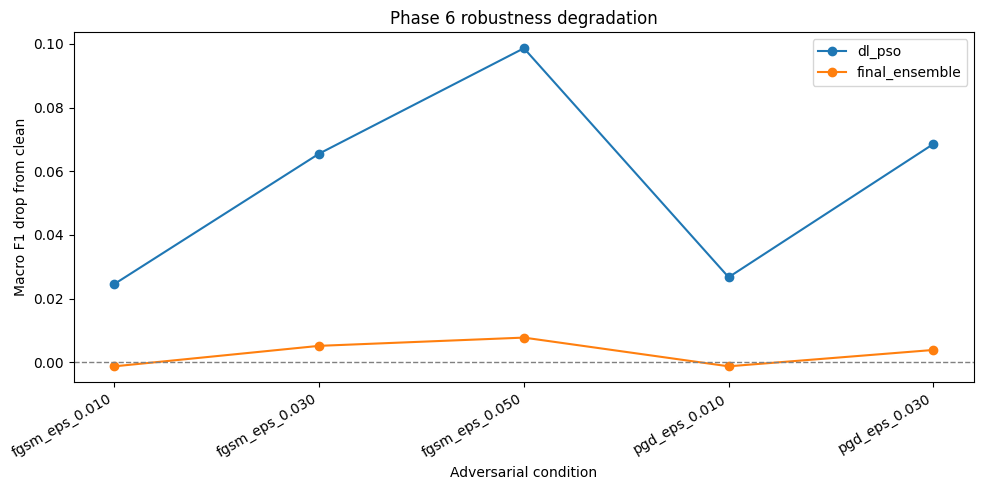

Saved robustness metrics: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase6_robustness_metrics.csv
Saved adversarial config: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase6_adversarial_config.csv
Saved metric drop figure: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/figures/phase6_robustness_metric_drop.png


In [18]:
# clean_baseline = ...: gán giá trị cho biến clean baseline
clean_baseline = robustness_metrics_df[robustness_metrics_df["condition"].eq("clean")][
    # ["model_variant", "threshold_strategy", "macro_f1", "precision_fake", "recall_fa...: ép kiểu chuỗi
    ["model_variant", "threshold_strategy", "macro_f1", "precision_fake", "recall_fake", "roc_auc", "pr_auc"]
# ].rename(: thực thi lệnh Python
].rename(
    # columns = ...: gán giá trị cho biến columns
    columns={
        # "macro_f1": "clean_macro_f1",: thực thi lệnh Python
        "macro_f1": "clean_macro_f1",
        # "precision_fake": "clean_precision_fake",: thực thi lệnh Python
        "precision_fake": "clean_precision_fake",
        # "recall_fake": "clean_recall_fake",: thực thi lệnh Python
        "recall_fake": "clean_recall_fake",
        # "roc_auc": "clean_roc_auc",: thực thi lệnh Python
        "roc_auc": "clean_roc_auc",
        # "pr_auc": "clean_pr_auc",: thực thi lệnh Python
        "pr_auc": "clean_pr_auc",
    # }: đóng khối từ điển
    }
# ): đóng ngoặc gọi hàm
)
# robustness_drop_df = ...: ghép hai DataFrame
robustness_drop_df = robustness_metrics_df.merge(clean_baseline, on=["model_variant", "threshold_strategy"], how="left")
# for: vòng lặp — for metric in ["macro_f1", "precision_fake", "recall_fake", 
for metric in ["macro_f1", "precision_fake", "recall_fake", "roc_auc", "pr_auc"]:
    # robustness_drop_df[f"{metric}_drop_from_clean"] = robustness_drop_df[f"clean_{me...: thực thi lệnh Python
    robustness_drop_df[f"{metric}_drop_from_clean"] = robustness_drop_df[f"clean_{metric}"] - robustness_drop_df[metric]
# robustness_drop_path = ...: gán giá trị cho biến robustness drop path
robustness_drop_path = REPORT_TABLE_DIR / "phase6_robustness_metric_drops.csv"
# robustness_drop_df.to_csv(robustness_drop_path, index=False): ghi DataFrame ra file CSV
robustness_drop_df.to_csv(robustness_drop_path, index=False)

# plot_df = ...: gán giá trị cho biến plot df
plot_df = robustness_drop_df[~robustness_drop_df["condition"].eq("clean")].copy()
# plt.figure(figsize=(10, 5)): tạo figure matplotlib mới
plt.figure(figsize=(10, 5))
# for: vòng lặp — for model_variant, group in plot_df.groupby("model_variant")
for model_variant, group in plot_df.groupby("model_variant"):
    # group = ...: gán giá trị cho biến group
    group = group.sort_values(["attack_method", "epsilon"])
    # plt.plot(group["condition"], group["macro_f1_drop_from_clean"], marker="o", labe...: vẽ đồ thị đường
    plt.plot(group["condition"], group["macro_f1_drop_from_clean"], marker="o", label=model_variant)
# plt.axhline(0, color="gray", linewidth=1, linestyle="--"): vẽ đường ngang tham chiếu
plt.axhline(0, color="gray", linewidth=1, linestyle="--")
# plt.ylabel("Macro F1 drop from clean"): đặt nhãn trục Y
plt.ylabel("Macro F1 drop from clean")
# plt.xlabel("Adversarial condition"): đặt nhãn trục X
plt.xlabel("Adversarial condition")
# plt.title("Phase 6 robustness degradation"): đặt tiêu đề biểu đồ
plt.title("Phase 6 robustness degradation")
# plt.xticks(rotation=30, ha="right"): thực thi lệnh Python
plt.xticks(rotation=30, ha="right")
# plt.legend(): hiển thị chú thích
plt.legend()
# plt.tight_layout(): tự chỉnh lề biểu đồ
plt.tight_layout()
# robustness_drop_figure_path = ...: gán giá trị cho biến robustness drop figure path
robustness_drop_figure_path = REPORT_FIGURE_DIR / "phase6_robustness_metric_drop.png"
# plt.savefig(robustness_drop_figure_path, dpi=160, bbox_inches="tight"): lưu biểu đồ ra file hình
plt.savefig(robustness_drop_figure_path, dpi=160, bbox_inches="tight")
# plt.show(): hiển thị biểu đồ
plt.show()

# print("Saved robustness metrics:", robustness_metrics_path): in thông tin ra console
print("Saved robustness metrics:", robustness_metrics_path)
# print("Saved adversarial config:", adversarial_config_path): in thông tin ra console
print("Saved adversarial config:", adversarial_config_path)
# print("Saved metric drop figure:", robustness_drop_figure_path): in thông tin ra console
print("Saved metric drop figure:", robustness_drop_figure_path)


## 3.3 SHAP Global XAI (Legacy PCA Appendix)

SHAP is computed on LightGBM for efficient global explanations in PCA space. Outputs rank PCA components and map important components back to raw feature groups when reducer loadings are available.


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


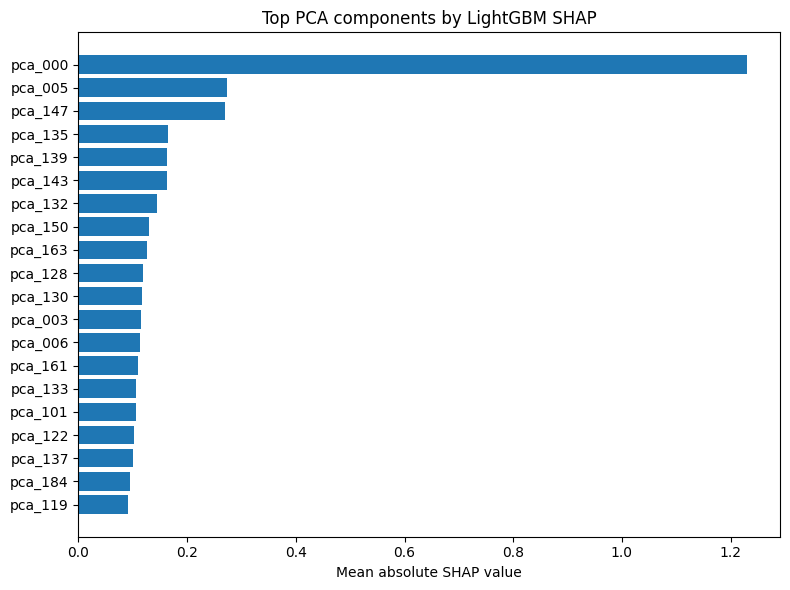

/tmp/ipykernel_1461/2551151616.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_fake, X_shap, feature_names=component_names, max_display=SHAP_MAX_DISPLAY, show=False)


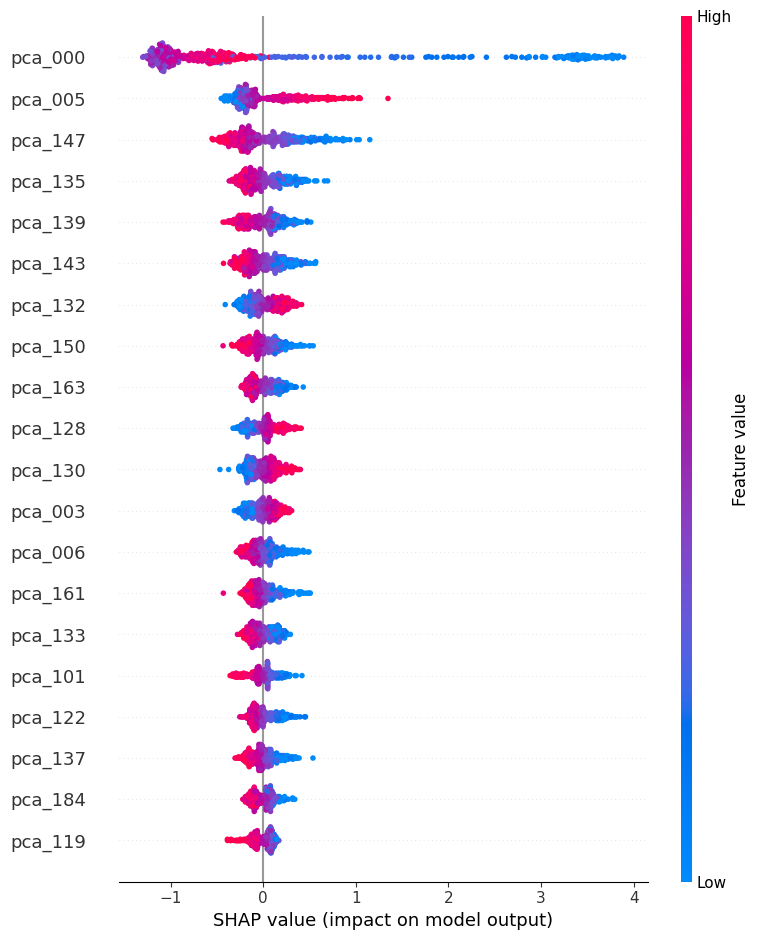

Saved SHAP values: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/xai/shap_values_lightgbm.npy
Saved SHAP importance: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase6_shap_global_importance.csv


,generated_at_utc,seed,subset_name,subset_size,model_variant,component_index,component_name,mean_abs_shap,rank
0,2026-06-11T06:21:41.737453+00:00,42,test_stratified_shap,500,lightgbm,0,pca_000,1.229513,1
5,2026-06-11T06:21:41.737453+00:00,42,test_stratified_shap,500,lightgbm,5,pca_005,0.273815,2
147,2026-06-11T06:21:41.737453+00:00,42,test_stratified_shap,500,lightgbm,147,pca_147,0.270464,3
135,2026-06-11T06:21:41.737453+00:00,42,test_stratified_shap,500,lightgbm,135,pca_135,0.164162,4
139,2026-06-11T06:21:41.737453+00:00,42,test_stratified_shap,500,lightgbm,139,pca_139,0.162487,5
143,2026-06-11T06:21:41.737453+00:00,42,test_stratified_shap,500,lightgbm,143,pca_143,0.162400,6
132,2026-06-11T06:21:41.737453+00:00,42,test_stratified_shap,500,lightgbm,132,pca_132,0.144969,7
150,2026-06-11T06:21:41.737453+00:00,42,test_stratified_shap,500,lightgbm,150,pca_150,0.129467,8
163,2026-06-11T06:21:41.737453+00:00,42,test_stratified_shap,500,lightgbm,163,pca_163,0.125740,9
128,2026-06-11T06:21:41.737453+00:00,42,test_stratified_shap,500,lightgbm,128,pca_128,0.119233,10


In [19]:
# component_names = ...: tạo dãy số cho vòng lặp
component_names = [f"pca_{idx:03d}" for idx in range(INPUT_DIM)]
# shap_idx = ...: tạo tập hợp
shap_idx = stratified_subset_indices(y["test"], SHAP_SUBSET_SIZE, SEED + 1)
# X_shap = ...: ép kiểu dữ liệu cột
X_shap = X["test"][shap_idx].astype(np.float32, copy=True)
# shap_subset_path = ...: tạo tập hợp
shap_subset_path = REPORT_TABLE_DIR / "phase6_shap_subset_indices.csv"
# pd.DataFrame({"seed": SEED, "split": "test", "row_index": shap_idx}).to_csv(shap...: ghi DataFrame ra file CSV
pd.DataFrame({"seed": SEED, "split": "test", "row_index": shap_idx}).to_csv(shap_subset_path, index=False)

# explainer = ...: gán giá trị cho biến explainer
explainer = shap.TreeExplainer(lgbm_model)
# raw_shap_values = ...: gán giá trị cho biến raw shap values
raw_shap_values = explainer.shap_values(X_shap)
# if: điều kiện — if isinstance(raw_shap_values, list):
if isinstance(raw_shap_values, list):
    # shap_values_fake = ...: ép kiểu số thực
    shap_values_fake = np.asarray(raw_shap_values[FAKE_LABEL], dtype=np.float32)
# else: nhánh còn lại của điều kiện
else:
    # shap_array = ...: ép kiểu số thực
    shap_array = np.asarray(raw_shap_values, dtype=np.float32)
    # if: điều kiện — if shap_array.ndim == 3:
    if shap_array.ndim == 3:
        # shap_values_fake = ...: gán giá trị cho biến shap values fake
        shap_values_fake = shap_array[:, :, FAKE_LABEL] if shap_array.shape[-1] > FAKE_LABEL else shap_array[:, :, 0]
    # else: nhánh còn lại của điều kiện
    else:
        # shap_values_fake = ...: gán giá trị cho biến shap values fake
        shap_values_fake = shap_array
# if: điều kiện — if shap_values_fake.shape[1] != INPUT_DIM:
if shap_values_fake.shape[1] != INPUT_DIM:
    # raise ValueError(f"SHAP feature dim mismatch: {shap_values_fake.shape} vs INPUT_...: ném lỗi và dừng cell
    raise ValueError(f"SHAP feature dim mismatch: {shap_values_fake.shape} vs INPUT_DIM={INPUT_DIM}")

# shap_values_path = ...: gán giá trị cho biến shap values path
shap_values_path = XAI_DIR / "shap_values_lightgbm.npy"
# np.save(shap_values_path, shap_values_fake.astype(np.float32)): lưu mảng numpy ra file .npy
np.save(shap_values_path, shap_values_fake.astype(np.float32))
# shap_importance = ...: tính trung bình
shap_importance = np.abs(shap_values_fake).mean(axis=0)
# shap_importance_df = ...: gán giá trị cho biến shap importance df
shap_importance_df = pd.DataFrame(
    # {: thực thi lệnh Python
    {
        # "generated_at_utc": utc_now(),: thực thi lệnh Python
        "generated_at_utc": utc_now(),
        # "seed": SEED,: thực thi lệnh Python
        "seed": SEED,
        # "subset_name": "test_stratified_shap",: tạo tập hợp
        "subset_name": "test_stratified_shap",
        # "subset_size": len(shap_idx),: đếm số phần tử
        "subset_size": len(shap_idx),
        # "model_variant": "lightgbm",: thực thi lệnh Python
        "model_variant": "lightgbm",
        # "component_index": np.arange(INPUT_DIM),: tạo dãy số cho vòng lặp
        "component_index": np.arange(INPUT_DIM),
        # "component_name": component_names,: thực thi lệnh Python
        "component_name": component_names,
        # "mean_abs_shap": shap_importance,: tính trung bình
        "mean_abs_shap": shap_importance,
    # }: đóng khối từ điển
    }
# ).sort_values("mean_abs_shap", ascending=False): tính trung bình
).sort_values("mean_abs_shap", ascending=False)
# shap_importance_df["rank"] = np.arange(1, len(shap_importance_df) + 1): tạo dãy số cho vòng lặp
shap_importance_df["rank"] = np.arange(1, len(shap_importance_df) + 1)
# shap_importance_path = ...: gán giá trị cho biến shap importance path
shap_importance_path = REPORT_TABLE_DIR / "phase6_shap_global_importance.csv"
# shap_importance_df.to_csv(shap_importance_path, index=False): ghi DataFrame ra file CSV
shap_importance_df.to_csv(shap_importance_path, index=False)

# top_shap = ...: xem vài dòng đầu
top_shap = shap_importance_df.head(SHAP_MAX_DISPLAY).sort_values("mean_abs_shap")
# plt.figure(figsize=(8, 6)): tạo figure matplotlib mới
plt.figure(figsize=(8, 6))
# plt.barh(top_shap["component_name"], top_shap["mean_abs_shap"], color="tab:blue"...: vẽ biểu đồ cột
plt.barh(top_shap["component_name"], top_shap["mean_abs_shap"], color="tab:blue")
# plt.xlabel("Mean absolute SHAP value"): đặt nhãn trục X
plt.xlabel("Mean absolute SHAP value")
# plt.title("Top PCA components by LightGBM SHAP"): đặt tiêu đề biểu đồ
plt.title("Top PCA components by LightGBM SHAP")
# plt.tight_layout(): tự chỉnh lề biểu đồ
plt.tight_layout()
# shap_top_figure_path = ...: gán giá trị cho biến shap top figure path
shap_top_figure_path = REPORT_FIGURE_DIR / "phase6_shap_top_components.png"
# plt.savefig(shap_top_figure_path, dpi=160, bbox_inches="tight"): lưu biểu đồ ra file hình
plt.savefig(shap_top_figure_path, dpi=160, bbox_inches="tight")
# plt.show(): hiển thị biểu đồ
plt.show()

# shap_summary_figure_path = ...: tính tổng
shap_summary_figure_path = REPORT_FIGURE_DIR / "phase6_shap_summary.png"
# try/except: khối xử lý ngoại lệ
try:
    # shap.summary_plot(shap_values_fake, X_shap, feature_names=component_names, max_d...: hiển thị bảng/kết quả trên notebook
    shap.summary_plot(shap_values_fake, X_shap, feature_names=component_names, max_display=SHAP_MAX_DISPLAY, show=False)
    # plt.tight_layout(): tự chỉnh lề biểu đồ
    plt.tight_layout()
    # plt.savefig(shap_summary_figure_path, dpi=160, bbox_inches="tight"): lưu biểu đồ ra file hình
    plt.savefig(shap_summary_figure_path, dpi=160, bbox_inches="tight")
    # plt.show(): hiển thị biểu đồ
    plt.show()
# except: xử lý ngoại lệ — except Exception as exc:
except Exception as exc:
    # record_fallback("shap_summary_plot", repr(exc), "saved_importance_bar_only"): tính tổng
    record_fallback("shap_summary_plot", repr(exc), "saved_importance_bar_only")
    # shap_summary_figure_path = ...: tính tổng
    shap_summary_figure_path = None

# print("Saved SHAP values:", shap_values_path): in thông tin ra console
print("Saved SHAP values:", shap_values_path)
# print("Saved SHAP importance:", shap_importance_path): in thông tin ra console
print("Saved SHAP importance:", shap_importance_path)
# display(shap_importance_df.head(20)): hiển thị bảng/kết quả trên notebook
display(shap_importance_df.head(20))


In [20]:
# build_raw_feature_metadata: hàm xử lý build raw feature metadata
def build_raw_feature_metadata() -> pd.DataFrame:
    # bert_dim = ...: ép kiểu số nguyên
    bert_dim = int(phase2_metadata.get("bert", {}).get("embedding_dim", 768)) if phase2_metadata else 768
    # behavioral_names = ...: gán giá trị cho biến behavioral names
    behavioral_names = phase2_metadata.get("behavioral_features", {}).get("all", []) if phase2_metadata else []
    # rows = ...: gán giá trị cho biến rows
    rows = [
        # {"raw_feature_index": idx, "raw_feature_name": f"bert_{idx:03d}", "raw_feature_g...: thực thi lệnh Python
        {"raw_feature_index": idx, "raw_feature_name": f"bert_{idx:03d}", "raw_feature_group": "bert_embedding", "formula": "BERT/ModernBERT pooled embedding dimension"}
        # for: vòng lặp — for idx in range(bert_dim)
        for idx in range(bert_dim)
    # ]: đóng khối danh sách
    ]
    # feature_dictionary = ...: đọc file CSV vào DataFrame
    feature_dictionary = pd.read_csv(FEATURE_DICTIONARY_PATH) if FEATURE_DICTIONARY_PATH.exists() else pd.DataFrame()
    # feature_lookup = ...: tạo dictionary
    feature_lookup = feature_dictionary.set_index("feature_name").to_dict(orient="index") if "feature_name" in feature_dictionary.columns else {}
    # for: vòng lặp — for offset, name in enumerate(behavioral_names):
    for offset, name in enumerate(behavioral_names):
        # meta = ...: gán giá trị cho biến meta
        meta = feature_lookup.get(name, {})
        # rows.append(: thực thi lệnh Python
        rows.append(
            # {: thực thi lệnh Python
            {
                # "raw_feature_index": bert_dim + offset,: tạo tập hợp
                "raw_feature_index": bert_dim + offset,
                # "raw_feature_name": name,: thực thi lệnh Python
                "raw_feature_name": name,
                # "raw_feature_group": "behavioral",: thực thi lệnh Python
                "raw_feature_group": "behavioral",
                # "behavioral_group": meta.get("feature_group", "unknown"),: thực thi lệnh Python
                "behavioral_group": meta.get("feature_group", "unknown"),
                # "formula": meta.get("formula", "behavioral feature"),: thực thi lệnh Python
                "formula": meta.get("formula", "behavioral feature"),
            # }: đóng khối từ điển
            }
        # ): đóng ngoặc gọi hàm
        )
    # return: trả kết quả từ hàm
    return pd.DataFrame(rows)


# extract_components_matrix: hàm xử lý extract components matrix
def extract_components_matrix(reducer_object: Any) -> np.ndarray | None:
    # if: điều kiện — if hasattr(reducer_object, "components_"):
    if hasattr(reducer_object, "components_"):
        # return: trả kết quả từ hàm
        return np.asarray(reducer_object.components_)
    # if: điều kiện — if isinstance(reducer_object, dict):
    if isinstance(reducer_object, dict):
        # for: vòng lặp — for key in ["reducer", "pca", "svd", "model"]:
        for key in ["reducer", "pca", "svd", "model"]:
            # if: điều kiện — if key in reducer_object and hasattr(reducer_object[key], "c
            if key in reducer_object and hasattr(reducer_object[key], "components_"):
                # return: trả kết quả từ hàm
                return np.asarray(reducer_object[key].components_)
    # return: trả kết quả từ hàm
    return None


# component_loading_rows = ...: gán giá trị cho biến component loading rows
component_loading_rows = []
# try/except: khối xử lý ngoại lệ
try:
    # reducer_object = ...: tải object đã lưu
    reducer_object = joblib.load(PCA_REDUCER_PATH)
    # components_matrix = ...: gán giá trị cho biến components matrix
    components_matrix = extract_components_matrix(reducer_object)
    # raw_feature_metadata = ...: gán giá trị cho biến raw feature metadata
    raw_feature_metadata = build_raw_feature_metadata()
    # if: điều kiện — if components_matrix is None:
    if components_matrix is None:
        # raise ValueError("Reducer does not expose components_"): ném lỗi và dừng cell
        raise ValueError("Reducer does not expose components_")
    # if: điều kiện — if len(raw_feature_metadata) != components_matrix.shape[1]:
    if len(raw_feature_metadata) != components_matrix.shape[1]:
        # record_fallback("pca_loading_map", f"raw feature metadata length {len(raw_featur...: đếm số phần tử
        record_fallback("pca_loading_map", f"raw feature metadata length {len(raw_feature_metadata)} != reducer raw dim {components_matrix.shape[1]}", "use_index_based_feature_names")
        # raw_feature_metadata = ...: gán giá trị cho biến raw feature metadata
        raw_feature_metadata = pd.DataFrame(
            # {: thực thi lệnh Python
            {
                # "raw_feature_index": np.arange(components_matrix.shape[1]),: tạo dãy số cho vòng lặp
                "raw_feature_index": np.arange(components_matrix.shape[1]),
                # "raw_feature_name": [f"raw_feature_{idx:03d}" for idx in range(components_matrix...: tạo dãy số cho vòng lặp
                "raw_feature_name": [f"raw_feature_{idx:03d}" for idx in range(components_matrix.shape[1])],
                # "raw_feature_group": ["unknown"] * components_matrix.shape[1],: thực thi lệnh Python
                "raw_feature_group": ["unknown"] * components_matrix.shape[1],
                # "formula": ["unknown"] * components_matrix.shape[1],: thực thi lệnh Python
                "formula": ["unknown"] * components_matrix.shape[1],
            # }: đóng khối từ điển
            }
        # ): đóng ngoặc gọi hàm
        )
    # top_components = ...: ép kiểu dữ liệu cột
    top_components = shap_importance_df.head(SHAP_MAX_DISPLAY)["component_index"].astype(int).tolist()
    # for: vòng lặp — for component_rank, component_index in enumerate(top_compone
    for component_rank, component_index in enumerate(top_components, start=1):
        # loadings = ...: gán giá trị cho biến loadings
        loadings = components_matrix[component_index]
        # top_raw_indices = ...: gán giá trị cho biến top raw indices
        top_raw_indices = np.argsort(np.abs(loadings))[::-1][:15]
        # shap_value = ...: ép kiểu số thực
        shap_value = float(shap_importance_df.loc[shap_importance_df["component_index"].eq(component_index), "mean_abs_shap"].iloc[0])
        # for: vòng lặp — for raw_rank, raw_index in enumerate(top_raw_indices, start=
        for raw_rank, raw_index in enumerate(top_raw_indices, start=1):
            # raw_meta = ...: tạo dictionary
            raw_meta = raw_feature_metadata.iloc[int(raw_index)].to_dict()
            # component_loading_rows.append(: thực thi lệnh Python
            component_loading_rows.append(
                # {: thực thi lệnh Python
                {
                    # "generated_at_utc": utc_now(),: thực thi lệnh Python
                    "generated_at_utc": utc_now(),
                    # "seed": SEED,: thực thi lệnh Python
                    "seed": SEED,
                    # "component_rank_by_shap": component_rank,: thực thi lệnh Python
                    "component_rank_by_shap": component_rank,
                    # "component_index": int(component_index),: ép kiểu số nguyên
                    "component_index": int(component_index),
                    # "component_name": f"pca_{component_index:03d}",: thực thi lệnh Python
                    "component_name": f"pca_{component_index:03d}",
                    # "component_mean_abs_shap": shap_value,: tính trung bình
                    "component_mean_abs_shap": shap_value,
                    # "raw_loading_rank": raw_rank,: thực thi lệnh Python
                    "raw_loading_rank": raw_rank,
                    # "raw_feature_index": int(raw_index),: ép kiểu số nguyên
                    "raw_feature_index": int(raw_index),
                    # "raw_feature_name": raw_meta.get("raw_feature_name", f"raw_feature_{raw_index:03...: thực thi lệnh Python
                    "raw_feature_name": raw_meta.get("raw_feature_name", f"raw_feature_{raw_index:03d}"),
                    # "raw_feature_group": raw_meta.get("raw_feature_group", "unknown"),: thực thi lệnh Python
                    "raw_feature_group": raw_meta.get("raw_feature_group", "unknown"),
                    # "behavioral_group": raw_meta.get("behavioral_group", ""),: thực thi lệnh Python
                    "behavioral_group": raw_meta.get("behavioral_group", ""),
                    # "loading_value": float(loadings[raw_index]),: ép kiểu số thực
                    "loading_value": float(loadings[raw_index]),
                    # "abs_loading_value": float(abs(loadings[raw_index])),: ép kiểu số thực
                    "abs_loading_value": float(abs(loadings[raw_index])),
                    # "formula": raw_meta.get("formula", ""),: thực thi lệnh Python
                    "formula": raw_meta.get("formula", ""),
                # }: đóng khối từ điển
                }
            # ): đóng ngoặc gọi hàm
            )
# except: xử lý ngoại lệ — except Exception as exc:
except Exception as exc:
    # record_fallback("pca_loading_map", repr(exc), "write_reason_row_only"): thực thi lệnh Python
    record_fallback("pca_loading_map", repr(exc), "write_reason_row_only")
    # component_loading_rows.append(: thực thi lệnh Python
    component_loading_rows.append(
        # {: thực thi lệnh Python
        {
            # "generated_at_utc": utc_now(),: thực thi lệnh Python
            "generated_at_utc": utc_now(),
            # "seed": SEED,: thực thi lệnh Python
            "seed": SEED,
            # "component_name": "not_available",: thực thi lệnh Python
            "component_name": "not_available",
            # "raw_feature_group": "unknown",: thực thi lệnh Python
            "raw_feature_group": "unknown",
            # "formula": f"PCA component loading map unavailable: {repr(exc)}",: thực thi lệnh Python
            "formula": f"PCA component loading map unavailable: {repr(exc)}",
        # }: đóng khối từ điển
        }
    # ): đóng ngoặc gọi hàm
    )

# pca_loading_map_df = ...: gán giá trị cho biến pca loading map df
pca_loading_map_df = pd.DataFrame(component_loading_rows)
# pca_loading_map_path = ...: gán giá trị cho biến pca loading map path
pca_loading_map_path = REPORT_TABLE_DIR / "phase6_pca_component_loading_map.csv"
# pca_loading_map_df.to_csv(pca_loading_map_path, index=False): ghi DataFrame ra file CSV
pca_loading_map_df.to_csv(pca_loading_map_path, index=False)
# display(pca_loading_map_df.head(30)): hiển thị bảng/kết quả trên notebook
display(pca_loading_map_df.head(30))
# print("Saved PCA component loading map:", pca_loading_map_path): in thông tin ra console
print("Saved PCA component loading map:", pca_loading_map_path)


,generated_at_utc,seed,component_rank_by_shap,component_index,component_name,component_mean_abs_shap,raw_loading_rank,raw_feature_index,raw_feature_name,raw_feature_group,behavioral_group,loading_value,abs_loading_value,formula
0,2026-06-11T06:21:55.701428+00:00,42,1,0,pca_000,1.229513,1,769,basic_word_count_log,behavioral,basic,0.093676,0.093676,log1p(word count of review text)
1,2026-06-11T06:21:55.701652+00:00,42,1,0,pca_000,1.229513,2,768,basic_char_len_log,behavioral,basic,0.092663,0.092663,log1p(character length of review text)
2,2026-06-11T06:21:55.701789+00:00,42,1,0,pca_000,1.229513,3,254,bert_254,bert_embedding,NaN,0.087012,0.087012,BERT/ModernBERT pooled embedding dimension
3,2026-06-11T06:21:55.701899+00:00,42,1,0,pca_000,1.229513,4,586,bert_586,bert_embedding,NaN,-0.083015,0.083015,BERT/ModernBERT pooled embedding dimension
4,2026-06-11T06:21:55.702009+00:00,42,1,0,pca_000,1.229513,5,142,bert_142,bert_embedding,NaN,-0.081456,0.081456,BERT/ModernBERT pooled embedding dimension
5,2026-06-11T06:21:55.702119+00:00,42,1,0,pca_000,1.229513,6,442,bert_442,bert_embedding,NaN,0.079148,0.079148,BERT/ModernBERT pooled embedding dimension
6,2026-06-11T06:21:55.702238+00:00,42,1,0,pca_000,1.229513,7,511,bert_511,bert_embedding,NaN,-0.078583,0.078583,BERT/ModernBERT pooled embedding dimension
7,2026-06-11T06:21:55.702360+00:00,42,1,0,pca_000,1.229513,8,251,bert_251,bert_embedding,NaN,0.076846,0.076846,BERT/ModernBERT pooled embedding dimension
8,2026-06-11T06:21:55.702491+00:00,42,1,0,pca_000,1.229513,9,606,bert_606,bert_embedding,NaN,-0.076159,0.076159,BERT/ModernBERT pooled embedding dimension
9,2026-06-11T06:21:55.702666+00:00,42,1,0,pca_000,1.229513,10,500,bert_500,bert_embedding,NaN,-0.075722,0.075722,BERT/ModernBERT pooled embedding dimension


Saved PCA component loading map: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase6_pca_component_loading_map.csv


## 3.4 LIME Local XAI (Legacy PCA Appendix)

LIME explains representative test cases using the legacy final ensemble predictor on PCA components.


In [21]:
# choose_case: hàm xử lý choose case
def choose_case(indices: np.ndarray, probabilities: np.ndarray, prefer: str) -> int | None:
    # if: điều kiện — if len(indices) == 0:
    if len(indices) == 0:
        # return: trả kết quả từ hàm
        return None
    # if: điều kiện — if prefer == "highest_fake_probability":
    if prefer == "highest_fake_probability":
        # return: trả kết quả từ hàm
        return int(indices[np.argmax(probabilities[indices])])
    # if: điều kiện — if prefer == "lowest_fake_probability":
    if prefer == "lowest_fake_probability":
        # return: trả kết quả từ hàm
        return int(indices[np.argmin(probabilities[indices])])
    # return: trả kết quả từ hàm
    return int(indices[0])


# select_lime_cases: hàm xử lý select lime cases
def select_lime_cases(prob_fake: np.ndarray, labels: np.ndarray) -> pd.DataFrame:
    # pred = ...: ép kiểu dữ liệu cột
    pred = (prob_fake >= selected_threshold).astype(int)
    # candidates = ...: gán giá trị cho biến candidates
    candidates = [
        # ("true_positive_fake", np.where((labels == FAKE_LABEL) & (pred == FAKE_LABEL))[0...: thực thi lệnh Python
        ("true_positive_fake", np.where((labels == FAKE_LABEL) & (pred == FAKE_LABEL))[0], "highest_fake_probability"),
        # ("true_negative_real", np.where((labels == REAL_LABEL) & (pred == REAL_LABEL))[0...: thực thi lệnh Python
        ("true_negative_real", np.where((labels == REAL_LABEL) & (pred == REAL_LABEL))[0], "lowest_fake_probability"),
        # ("false_positive_real_as_fake", np.where((labels == REAL_LABEL) & (pred == FAKE_...: thực thi lệnh Python
        ("false_positive_real_as_fake", np.where((labels == REAL_LABEL) & (pred == FAKE_LABEL))[0], "highest_fake_probability"),
        # ("false_negative_fake_as_real", np.where((labels == FAKE_LABEL) & (pred == REAL_...: thực thi lệnh Python
        ("false_negative_fake_as_real", np.where((labels == FAKE_LABEL) & (pred == REAL_LABEL))[0], "lowest_fake_probability"),
        # ("highest_confidence_fake_prediction", np.where(pred == FAKE_LABEL)[0], "highest...: dự đoán nhãn/xác suất
        ("highest_confidence_fake_prediction", np.where(pred == FAKE_LABEL)[0], "highest_fake_probability"),
        # ("highest_confidence_real_prediction", np.where(pred == REAL_LABEL)[0], "lowest_...: dự đoán nhãn/xác suất
        ("highest_confidence_real_prediction", np.where(pred == REAL_LABEL)[0], "lowest_fake_probability"),
    # ]: đóng khối danh sách
    ]
    # used = ...: tạo tập hợp
    used = set()
    # rows = ...: gán giá trị cho biến rows
    rows = []
    # for: vòng lặp — for case_type, candidate_idx, prefer in candidates:
    for case_type, candidate_idx, prefer in candidates:
        # available = ...: ép kiểu số nguyên
        available = np.asarray([idx for idx in candidate_idx if int(idx) not in used], dtype=int)
        # selected = ...: gán giá trị cho biến selected
        selected = choose_case(available, prob_fake, prefer)
        # if: điều kiện — if selected is None:
        if selected is None:
            # record_fallback("lime_case_selection", f"No available rows for {case_type}", "ca...: thực thi lệnh Python
            record_fallback("lime_case_selection", f"No available rows for {case_type}", "case_skipped")
            continue
        # used.add(int(selected)): ép kiểu số nguyên
        used.add(int(selected))
        # rows.append(: thực thi lệnh Python
        rows.append(
            # {: thực thi lệnh Python
            {
                # "case_type": case_type,: thực thi lệnh Python
                "case_type": case_type,
                # "test_row_index": int(selected),: ép kiểu số nguyên
                "test_row_index": int(selected),
                # "true_label": int(labels[selected]),: ép kiểu số nguyên
                "true_label": int(labels[selected]),
                # "predicted_label": int(pred[selected]),: dự đoán nhãn/xác suất
                "predicted_label": int(pred[selected]),
                # "probability_fake": float(prob_fake[selected]),: ép kiểu số thực
                "probability_fake": float(prob_fake[selected]),
                # "selected_threshold": float(selected_threshold),: ép kiểu số thực
                "selected_threshold": float(selected_threshold),
                # "threshold_strategy": "phase5_selected_threshold",: ép kiểu chuỗi
                "threshold_strategy": "phase5_selected_threshold",
            # }: đóng khối từ điển
            }
        # ): đóng ngoặc gọi hàm
        )
        # if: điều kiện — if len(rows) >= LIME_NUM_CASES:
        if len(rows) >= LIME_NUM_CASES:
            break
    # return: trả kết quả từ hàm
    return pd.DataFrame(rows)


# lime_background_idx = ...: làm tròn số
lime_background_idx = stratified_subset_indices(y["train"], LIME_BACKGROUND_SIZE, SEED + 2)
# X_lime_background = ...: ép kiểu dữ liệu cột
X_lime_background = X["train"][lime_background_idx].astype(np.float32, copy=True)
# test_final_prob = ...: dự đoán nhãn/xác suất
test_final_prob = predict_final_ensemble_fake_proba(X["test"])
# lime_cases_df = ...: gán giá trị cho biến lime cases df
lime_cases_df = select_lime_cases(test_final_prob, y["test"])
# if: điều kiện — if len(lime_cases_df) < 4:
if len(lime_cases_df) < 4:
    # record_fallback("lime_case_selection", f"Only {len(lime_cases_df)} representativ...: đếm số phần tử
    record_fallback("lime_case_selection", f"Only {len(lime_cases_df)} representative cases available", "continue_with_available_cases")

# lime_background_path = ...: làm tròn số
lime_background_path = REPORT_TABLE_DIR / "phase6_lime_background_indices.csv"
# pd.DataFrame({"seed": SEED, "split": "train", "row_index": lime_background_idx})...: ghi DataFrame ra file CSV
pd.DataFrame({"seed": SEED, "split": "train", "row_index": lime_background_idx}).to_csv(lime_background_path, index=False)

# explainer = ...: gán giá trị cho biến explainer
explainer = lime_tabular.LimeTabularExplainer(
    # training_data = ...: làm tròn số
    training_data=X_lime_background,
    # feature_names = ...: gán giá trị cho biến feature names
    feature_names=component_names,
    # class_names = ...: gán giá trị cho biến class names
    class_names=["real", "fake"],
    # mode = ...: gán giá trị cho biến mode
    mode="classification",
    # discretize_continuous = ...: gán giá trị cho biến discretize continuous
    discretize_continuous=True,
    # random_state = ...: gán giá trị cho biến random state
    random_state=SEED,
# ): đóng ngoặc gọi hàm
)

# lime_weight_rows = ...: gán giá trị cho biến lime weight rows
lime_weight_rows = []
# case_summary_rows = ...: tính tổng
case_summary_rows = []
# for: vòng lặp — for case_number, case in enumerate(lime_cases_df.to_dict(ori
for case_number, case in enumerate(lime_cases_df.to_dict(orient="records"), start=1):
    # row_index = ...: ép kiểu số nguyên
    row_index = int(case["test_row_index"])
    # explanation = ...: gán giá trị cho biến explanation
    explanation = explainer.explain_instance(
        # X["test"][row_index],: thực thi lệnh Python
        X["test"][row_index],
        # predict_final_ensemble_proba,: dự đoán nhãn/xác suất
        predict_final_ensemble_proba,
        # num_features = ...: gán giá trị cho biến num features
        num_features=LIME_NUM_FEATURES,
        # labels = ...: gán giá trị cho biến labels
        labels=[FAKE_LABEL],
    # ): đóng ngoặc gọi hàm
    )
    # safe_case_type = ...: ép kiểu chuỗi
    safe_case_type = str(case["case_type"]).replace("/", "_").replace(" ", "_")
    # html_path = ...: gán giá trị cho biến html path
    html_path = XAI_DIR / f"lime_case_{case_number:02d}_{safe_case_type}.html"
    # explanation.save_to_file(str(html_path)): ép kiểu chuỗi
    explanation.save_to_file(str(html_path))
    # case_summary_rows.append(: tính tổng
    case_summary_rows.append(
        # {: thực thi lệnh Python
        {
            # "generated_at_utc": utc_now(),: thực thi lệnh Python
            "generated_at_utc": utc_now(),
            # "seed": SEED,: thực thi lệnh Python
            "seed": SEED,
            # "case_number": case_number,: thực thi lệnh Python
            "case_number": case_number,
            # "case_type": case["case_type"],: thực thi lệnh Python
            "case_type": case["case_type"],
            # "split": "test",: thực thi lệnh Python
            "split": "test",
            # "test_row_index": row_index,: thực thi lệnh Python
            "test_row_index": row_index,
            # "true_label": int(case["true_label"]),: ép kiểu số nguyên
            "true_label": int(case["true_label"]),
            # "predicted_label": int(case["predicted_label"]),: dự đoán nhãn/xác suất
            "predicted_label": int(case["predicted_label"]),
            # "probability_fake": float(case["probability_fake"]),: ép kiểu số thực
            "probability_fake": float(case["probability_fake"]),
            # "selected_threshold": float(case["selected_threshold"]),: ép kiểu số thực
            "selected_threshold": float(case["selected_threshold"]),
            # "threshold_strategy": case["threshold_strategy"],: ép kiểu chuỗi
            "threshold_strategy": case["threshold_strategy"],
            # "lime_html_path": str(html_path),: ép kiểu chuỗi
            "lime_html_path": str(html_path),
        # }: đóng khối từ điển
        }
    # ): đóng ngoặc gọi hàm
    )
    # for: vòng lặp — for feature_rank, (feature_rule, weight) in enumerate(explan
    for feature_rank, (feature_rule, weight) in enumerate(explanation.as_list(label=FAKE_LABEL), start=1):
        # lime_weight_rows.append(: thực thi lệnh Python
        lime_weight_rows.append(
            # {: thực thi lệnh Python
            {
                # "generated_at_utc": utc_now(),: thực thi lệnh Python
                "generated_at_utc": utc_now(),
                # "seed": SEED,: thực thi lệnh Python
                "seed": SEED,
                # "case_number": case_number,: thực thi lệnh Python
                "case_number": case_number,
                # "case_type": case["case_type"],: thực thi lệnh Python
                "case_type": case["case_type"],
                # "test_row_index": row_index,: thực thi lệnh Python
                "test_row_index": row_index,
                # "feature_rank": feature_rank,: thực thi lệnh Python
                "feature_rank": feature_rank,
                # "lime_feature_rule": feature_rule,: thực thi lệnh Python
                "lime_feature_rule": feature_rule,
                # "lime_weight_for_fake": float(weight),: ép kiểu số thực
                "lime_weight_for_fake": float(weight),
                # "selected_threshold": float(selected_threshold),: ép kiểu số thực
                "selected_threshold": float(selected_threshold),
                # "model_variant": "final_ensemble",: thực thi lệnh Python
                "model_variant": "final_ensemble",
            # }: đóng khối từ điển
            }
        # ): đóng ngoặc gọi hàm
        )

# lime_case_summary_df = ...: tính tổng
lime_case_summary_df = pd.DataFrame(case_summary_rows)
# lime_feature_weights_df = ...: gán giá trị cho biến lime feature weights df
lime_feature_weights_df = pd.DataFrame(lime_weight_rows)
# lime_case_summary_path = ...: tính tổng
lime_case_summary_path = REPORT_TABLE_DIR / "phase6_lime_case_summary.csv"
# lime_feature_weights_path = ...: gán giá trị cho biến lime feature weights path
lime_feature_weights_path = REPORT_TABLE_DIR / "phase6_lime_feature_weights.csv"
# lime_case_summary_df.to_csv(lime_case_summary_path, index=False): ghi DataFrame ra file CSV
lime_case_summary_df.to_csv(lime_case_summary_path, index=False)
# lime_feature_weights_df.to_csv(lime_feature_weights_path, index=False): ghi DataFrame ra file CSV
lime_feature_weights_df.to_csv(lime_feature_weights_path, index=False)
# display(lime_case_summary_df): hiển thị bảng/kết quả trên notebook
display(lime_case_summary_df)
# display(lime_feature_weights_df.head(30)): hiển thị bảng/kết quả trên notebook
display(lime_feature_weights_df.head(30))
# print("Saved LIME case summary:", lime_case_summary_path): in thông tin ra console
print("Saved LIME case summary:", lime_case_summary_path)
# print("Saved LIME weights:", lime_feature_weights_path): in thông tin ra console
print("Saved LIME weights:", lime_feature_weights_path)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

,generated_at_utc,seed,case_number,case_type,split,test_row_index,true_label,predicted_label,probability_fake,selected_threshold,threshold_strategy,lime_html_path
0,2026-06-11T06:22:05.628493+00:00,42,1,true_positive_fake,test,2892,1,1,0.997671,0.79,phase5_selected_threshold,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...
1,2026-06-11T06:22:07.822004+00:00,42,2,true_negative_real,test,112,0,0,0.030385,0.79,phase5_selected_threshold,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...
2,2026-06-11T06:22:10.108503+00:00,42,3,false_positive_real_as_fake,test,2058,0,1,0.993672,0.79,phase5_selected_threshold,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...
3,2026-06-11T06:22:11.790060+00:00,42,4,false_negative_fake_as_real,test,5514,1,0,0.038811,0.79,phase5_selected_threshold,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...
4,2026-06-11T06:22:13.385945+00:00,42,5,highest_confidence_fake_prediction,test,2004,1,1,0.997100,0.79,phase5_selected_threshold,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...
5,2026-06-11T06:22:14.942461+00:00,42,6,highest_confidence_real_prediction,test,4942,0,0,0.031263,0.79,phase5_selected_threshold,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...


,generated_at_utc,seed,case_number,case_type,test_row_index,feature_rank,lime_feature_rule,lime_weight_for_fake,selected_threshold,model_variant
0,2026-06-11T06:22:05.628546+00:00,42,1,true_positive_fake,2892,1,pca_000 <= -8.05,0.552377,0.79,final_ensemble
1,2026-06-11T06:22:05.628555+00:00,42,1,true_positive_fake,2892,2,pca_005 > 2.73,0.118126,0.79,final_ensemble
2,2026-06-11T06:22:05.628579+00:00,42,1,true_positive_fake,2892,3,pca_143 <= -0.74,0.066534,0.79,final_ensemble
3,2026-06-11T06:22:05.628585+00:00,42,1,true_positive_fake,2892,4,pca_135 <= -0.70,0.058791,0.79,final_ensemble
4,2026-06-11T06:22:05.628590+00:00,42,1,true_positive_fake,2892,5,pca_139 <= -0.60,0.051571,0.79,final_ensemble
5,2026-06-11T06:22:05.628596+00:00,42,1,true_positive_fake,2892,6,pca_132 <= -0.64,-0.046420,0.79,final_ensemble
6,2026-06-11T06:22:05.628609+00:00,42,1,true_positive_fake,2892,7,pca_137 <= -0.62,0.044701,0.79,final_ensemble
7,2026-06-11T06:22:05.628615+00:00,42,1,true_positive_fake,2892,8,pca_122 <= -0.67,0.043830,0.79,final_ensemble
8,2026-06-11T06:22:05.628621+00:00,42,1,true_positive_fake,2892,9,pca_003 > 2.28,0.042637,0.79,final_ensemble
9,2026-06-11T06:22:05.628627+00:00,42,1,true_positive_fake,2892,10,pca_101 <= -0.75,0.036280,0.79,final_ensemble


Saved LIME case summary: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase6_lime_case_summary.csv
Saved LIME weights: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase6_lime_feature_weights.csv


## 4. Phase 6 Metadata

Metadata records final-track XAI outputs, legacy appendix outputs, fallback decisions, and limitations.


In [22]:
# phase6_final_output_paths = ...: gán giá trị cho biến phase6 final output paths
phase6_final_output_paths = {
    # "input_validation": str(final_validation_path),: ép kiểu chuỗi
    "input_validation": str(final_validation_path),
    # "shap_subset_indices": str(final_shap_subset_path),: tạo tập hợp
    "shap_subset_indices": str(final_shap_subset_path),
    # "shap_values_xgb": str(final_shap_values_path),: ép kiểu chuỗi
    "shap_values_xgb": str(final_shap_values_path),
    # "shap_global_importance": str(final_shap_importance_path),: ép kiểu chuỗi
    "shap_global_importance": str(final_shap_importance_path),
    # "shap_block_importance": str(final_block_importance_path),: ép kiểu chuỗi
    "shap_block_importance": str(final_block_importance_path),
    # "shap_top_behavioral_figure": str(final_shap_top_figure_path) if final_shap_top_...: ép kiểu chuỗi
    "shap_top_behavioral_figure": str(final_shap_top_figure_path) if final_shap_top_figure_path else None,
    # "shap_summary_behavioral_figure": str(final_shap_summary_figure_path) if final_s...: ép kiểu chuỗi
    "shap_summary_behavioral_figure": str(final_shap_summary_figure_path) if final_shap_summary_figure_path else None,
    # "lime_background_indices": str(final_lime_background_path),: làm tròn số
    "lime_background_indices": str(final_lime_background_path),
    # "lime_case_summary": str(final_lime_case_summary_path),: ép kiểu chuỗi
    "lime_case_summary": str(final_lime_case_summary_path),
    # "lime_feature_weights": str(final_lime_feature_weights_path),: ép kiểu chuỗi
    "lime_feature_weights": str(final_lime_feature_weights_path),
    # "lime_html_files": final_lime_case_summary_df["lime_html_path"].tolist() if not ...: chuyển/chiếu thành list
    "lime_html_files": final_lime_case_summary_df["lime_html_path"].tolist() if not final_lime_case_summary_df.empty else [],
# }: đóng khối từ điển
}

# phase6_legacy_output_paths = ...: gán giá trị cho biến phase6 legacy output paths
phase6_legacy_output_paths = {
    # "input_validation": str(input_validation_path),: ép kiểu chuỗi
    "input_validation": str(input_validation_path),
    # "artifact_validation": str(artifact_validation_path),: ép kiểu chuỗi
    "artifact_validation": str(artifact_validation_path),
    # "predictor_smoke_test": str(predictor_smoke_path),: dự đoán nhãn/xác suất
    "predictor_smoke_test": str(predictor_smoke_path),
    # "robustness_subset_indices": str(robustness_subset_path),: tạo tập hợp
    "robustness_subset_indices": str(robustness_subset_path),
    # "robustness_metrics": str(robustness_metrics_path),: ép kiểu chuỗi
    "robustness_metrics": str(robustness_metrics_path),
    # "robustness_metric_drops": str(robustness_drop_path),: ép kiểu chuỗi
    "robustness_metric_drops": str(robustness_drop_path),
    # "adversarial_config": str(adversarial_config_path),: ép kiểu chuỗi
    "adversarial_config": str(adversarial_config_path),
    # "robustness_metric_drop_figure": str(robustness_drop_figure_path),: ép kiểu chuỗi
    "robustness_metric_drop_figure": str(robustness_drop_figure_path),
    # "shap_subset_indices": str(shap_subset_path),: tạo tập hợp
    "shap_subset_indices": str(shap_subset_path),
    # "shap_values_lightgbm": str(shap_values_path),: ép kiểu chuỗi
    "shap_values_lightgbm": str(shap_values_path),
    # "shap_global_importance": str(shap_importance_path),: ép kiểu chuỗi
    "shap_global_importance": str(shap_importance_path),
    # "shap_top_components_figure": str(shap_top_figure_path),: ép kiểu chuỗi
    "shap_top_components_figure": str(shap_top_figure_path),
    # "shap_summary_figure": str(shap_summary_figure_path) if shap_summary_figure_path...: ép kiểu chuỗi
    "shap_summary_figure": str(shap_summary_figure_path) if shap_summary_figure_path else None,
    # "pca_component_loading_map": str(pca_loading_map_path),: ép kiểu chuỗi
    "pca_component_loading_map": str(pca_loading_map_path),
    # "lime_background_indices": str(lime_background_path),: làm tròn số
    "lime_background_indices": str(lime_background_path),
    # "lime_case_summary": str(lime_case_summary_path),: ép kiểu chuỗi
    "lime_case_summary": str(lime_case_summary_path),
    # "lime_feature_weights": str(lime_feature_weights_path),: ép kiểu chuỗi
    "lime_feature_weights": str(lime_feature_weights_path),
    # "lime_html_files": lime_case_summary_df["lime_html_path"].tolist() if not lime_c...: chuyển/chiếu thành list
    "lime_html_files": lime_case_summary_df["lime_html_path"].tolist() if not lime_case_summary_df.empty else [],
# }: đóng khối từ điển
}

# phase6_final_metadata = ...: gán giá trị cho biến phase6 final metadata
phase6_final_metadata = {
    # "generated_at_utc": utc_now(),: thực thi lệnh Python
    "generated_at_utc": utc_now(),
    # "seed": SEED,: thực thi lệnh Python
    "seed": SEED,
    # "track": "final_raw_777",: thực thi lệnh Python
    "track": "final_raw_777",
    # "project_root": str(PROJECT_ROOT),: ép kiểu chuỗi
    "project_root": str(PROJECT_ROOT),
    # "input_dim": RAW_INPUT_DIM,: thực thi lệnh Python
    "input_dim": RAW_INPUT_DIM,
    # "model_variant": "phase5_xgb_raw",: thực thi lệnh Python
    "model_variant": "phase5_xgb_raw",
    # "case_selection_model_variant": "phase5_weighted_blend",: đếm số phần tử
    "case_selection_model_variant": "phase5_weighted_blend",
    # "balanced_threshold": balanced_threshold,: thực thi lệnh Python
    "balanced_threshold": balanced_threshold,
    # "precision_first_threshold": precision_first_threshold,: thực thi lệnh Python
    "precision_first_threshold": precision_first_threshold,
    # "lime_threshold": final_lime_threshold,: thực thi lệnh Python
    "lime_threshold": final_lime_threshold,
    # "lime_threshold_strategy": final_lime_threshold_strategy,: ép kiểu chuỗi
    "lime_threshold_strategy": final_lime_threshold_strategy,
    # "subset_sizes": {: tạo tập hợp
    "subset_sizes": {
        # "shap_requested": SHAP_SUBSET_SIZE,: thực thi lệnh Python
        "shap_requested": SHAP_SUBSET_SIZE,
        # "shap_actual": int(len(final_shap_idx)),: đếm số phần tử
        "shap_actual": int(len(final_shap_idx)),
        # "lime_background_requested": LIME_BACKGROUND_SIZE,: làm tròn số
        "lime_background_requested": LIME_BACKGROUND_SIZE,
        # "lime_background_actual": int(len(final_lime_background_idx)),: làm tròn số
        "lime_background_actual": int(len(final_lime_background_idx)),
        # "lime_cases_requested": LIME_NUM_CASES,: thực thi lệnh Python
        "lime_cases_requested": LIME_NUM_CASES,
        # "lime_cases_actual": int(len(final_lime_case_summary_df)),: đếm số phần tử
        "lime_cases_actual": int(len(final_lime_case_summary_df)),
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "source_artifacts": {: thực thi lệnh Python
    "source_artifacts": {
        # "phase2_metadata": str(PHASE2_METADATA_PATH),: ép kiểu chuỗi
        "phase2_metadata": str(PHASE2_METADATA_PATH),
        # "phase5_metadata": str(PHASE5_METADATA_PATH),: ép kiểu chuỗi
        "phase5_metadata": str(PHASE5_METADATA_PATH),
        # "phase5_xgb_raw": str(PHASE5_XGB_RAW_PATH),: ép kiểu chuỗi
        "phase5_xgb_raw": str(PHASE5_XGB_RAW_PATH),
        # "phase5_weighted_blend_metadata": str(PHASE5_WEIGHTED_BLEND_METADATA_PATH),: đếm số phần tử
        "phase5_weighted_blend_metadata": str(PHASE5_WEIGHTED_BLEND_METADATA_PATH),
        # "phase5_weighted_blend_test_prob": str(PHASE5_BLEND_TEST_PROB_PATH),: đếm số phần tử
        "phase5_weighted_blend_test_prob": str(PHASE5_BLEND_TEST_PROB_PATH),
        # "features_raw_test": str(FINAL_RAW_FEATURE_PATHS["test"]),: ép kiểu chuỗi
        "features_raw_test": str(FINAL_RAW_FEATURE_PATHS["test"]),
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "outputs": phase6_final_output_paths,: thực thi lệnh Python
    "outputs": phase6_final_output_paths,
    # "fallback_decisions": [item for item in PHASE6_FALLBACKS if str(item.get("kind",...: ép kiểu chuỗi
    "fallback_decisions": [item for item in PHASE6_FALLBACKS if str(item.get("kind", "")).startswith("final")],
    # "known_limitations": [: thực thi lệnh Python
    "known_limitations": [
        # "SHAP on 768 BERT dimensions is reported per-dimension and as an aggregate block...: thực thi lệnh Python
        "SHAP on 768 BERT dimensions is reported per-dimension and as an aggregate block; semantic token attribution requires a separate text-level method.",
        # "LIME cases are selected with weighted-blend probabilities but explained with th...: xóa biến để giải phóng RAM/VRAM
        "LIME cases are selected with weighted-blend probabilities but explained with the XGB raw tabular model (50% of the blend).",
        # "No adversarial robustness claim is made for the final raw tabular + sequence pi...: thực thi lệnh Python
        "No adversarial robustness claim is made for the final raw tabular + sequence pipeline in this notebook.",
    # ],: đóng phần tử danh sách (còn phần tử sau)
    ],
# }: đóng khối từ điển
}

# phase6_final_metadata_path = ...: gán giá trị cho biến phase6 final metadata path
phase6_final_metadata_path = XAI_DIR / "phase6_final_metadata.json"
# with: context manager — with phase6_final_metadata_path.open("w", encoding="utf-8") 
with phase6_final_metadata_path.open("w", encoding="utf-8") as file:
    # json.dump(phase6_final_metadata, file, indent=2): ghi dictionary ra JSON
    json.dump(phase6_final_metadata, file, indent=2)

# phase6_metadata = ...: gán giá trị cho biến phase6 metadata
phase6_metadata = {
    # "generated_at_utc": utc_now(),: thực thi lệnh Python
    "generated_at_utc": utc_now(),
    # "seed": SEED,: thực thi lệnh Python
    "seed": SEED,
    # "project_root": str(PROJECT_ROOT),: ép kiểu chuỗi
    "project_root": str(PROJECT_ROOT),
    # "device": str(DEVICE),: ép kiểu chuỗi
    "device": str(DEVICE),
    # "headline_track": "final_raw_777",: xem vài dòng đầu
    "headline_track": "final_raw_777",
    # "legacy_appendix_track": "pca_400",: thực thi lệnh Python
    "legacy_appendix_track": "pca_400",
    # "final_track_metadata": str(phase6_final_metadata_path),: ép kiểu chuỗi
    "final_track_metadata": str(phase6_final_metadata_path),
    # "input_dim_legacy": INPUT_DIM,: thực thi lệnh Python
    "input_dim_legacy": INPUT_DIM,
    # "subset_sizes": {: tạo tập hợp
    "subset_sizes": {
        # "robustness_requested": ROBUSTNESS_SUBSET_SIZE,: thực thi lệnh Python
        "robustness_requested": ROBUSTNESS_SUBSET_SIZE,
        # "robustness_actual": int(len(robustness_idx)),: đếm số phần tử
        "robustness_actual": int(len(robustness_idx)),
        # "shap_requested": SHAP_SUBSET_SIZE,: thực thi lệnh Python
        "shap_requested": SHAP_SUBSET_SIZE,
        # "shap_actual": int(len(shap_idx)),: đếm số phần tử
        "shap_actual": int(len(shap_idx)),
        # "lime_background_requested": LIME_BACKGROUND_SIZE,: làm tròn số
        "lime_background_requested": LIME_BACKGROUND_SIZE,
        # "lime_background_actual": int(len(lime_background_idx)),: làm tròn số
        "lime_background_actual": int(len(lime_background_idx)),
        # "lime_cases_requested": LIME_NUM_CASES,: thực thi lệnh Python
        "lime_cases_requested": LIME_NUM_CASES,
        # "lime_cases_actual": int(len(lime_case_summary_df)),: đếm số phần tử
        "lime_cases_actual": int(len(lime_case_summary_df)),
        # "final_shap_actual": int(len(final_shap_idx)),: đếm số phần tử
        "final_shap_actual": int(len(final_shap_idx)),
        # "final_lime_cases_actual": int(len(final_lime_case_summary_df)),: đếm số phần tử
        "final_lime_cases_actual": int(len(final_lime_case_summary_df)),
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "adversarial_config": {: thực thi lệnh Python
    "adversarial_config": {
        # "attack_space": "pca_feature_space",: thực thi lệnh Python
        "attack_space": "pca_feature_space",
        # "surrogate_model": "dl_pso",: thực thi lệnh Python
        "surrogate_model": "dl_pso",
        # "fgsm_epsilons": FGSM_EPSILONS,: thực thi lệnh Python
        "fgsm_epsilons": FGSM_EPSILONS,
        # "pgd_epsilons": PGD_EPSILONS,: thực thi lệnh Python
        "pgd_epsilons": PGD_EPSILONS,
        # "pgd_steps": PGD_STEPS,: thực thi lệnh Python
        "pgd_steps": PGD_STEPS,
        # "feature_clamp": "train_pca_component_min_max",: lấy giá trị nhỏ nhất
        "feature_clamp": "train_pca_component_min_max",
        # "applies_to": "legacy_appendix_only",: thực thi lệnh Python
        "applies_to": "legacy_appendix_only",
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "source_artifacts": {: thực thi lệnh Python
    "source_artifacts": {
        # "phase2_metadata": str(PHASE2_METADATA_PATH),: ép kiểu chuỗi
        "phase2_metadata": str(PHASE2_METADATA_PATH),
        # "phase5_xgb_raw": str(PHASE5_XGB_RAW_PATH),: ép kiểu chuỗi
        "phase5_xgb_raw": str(PHASE5_XGB_RAW_PATH),
        # "phase5_weighted_blend_test_prob": str(PHASE5_BLEND_TEST_PROB_PATH),: đếm số phần tử
        "phase5_weighted_blend_test_prob": str(PHASE5_BLEND_TEST_PROB_PATH),
        # "phase3_metadata": str(PHASE3_METADATA_PATH),: ép kiểu chuỗi
        "phase3_metadata": str(PHASE3_METADATA_PATH),
        # "pca_reducer": str(PCA_REDUCER_PATH),: ép kiểu chuỗi
        "pca_reducer": str(PCA_REDUCER_PATH),
        # "phase4_metadata": str(PHASE4_METADATA_PATH),: ép kiểu chuỗi
        "phase4_metadata": str(PHASE4_METADATA_PATH),
        # "best_model_dl": str(BEST_MODEL_PATH),: ép kiểu chuỗi
        "best_model_dl": str(BEST_MODEL_PATH),
        # "best_params": str(BEST_PARAMS_PATH),: ép kiểu chuỗi
        "best_params": str(BEST_PARAMS_PATH),
        # "phase5_metadata": str(PHASE5_METADATA_PATH),: ép kiểu chuỗi
        "phase5_metadata": str(PHASE5_METADATA_PATH),
        # "final_ensemble_model": str(FINAL_ENSEMBLE_MODEL_PATH),: ép kiểu chuỗi
        "final_ensemble_model": str(FINAL_ENSEMBLE_MODEL_PATH),
        # "xgboost_model": str(XGBOOST_MODEL_PATH),: ép kiểu chuỗi
        "xgboost_model": str(XGBOOST_MODEL_PATH),
        # "lightgbm_model": str(LIGHTGBM_MODEL_PATH),: ép kiểu chuỗi
        "lightgbm_model": str(LIGHTGBM_MODEL_PATH),
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "selected_phase5_candidate_legacy": {: thực thi lệnh Python
    "selected_phase5_candidate_legacy": {
        # "name": selected_candidate_name,: thực thi lệnh Python
        "name": selected_candidate_name,
        # "config": selected_candidate_config,: thực thi lệnh Python
        "config": selected_candidate_config,
        # "selected_threshold": selected_threshold,: thực thi lệnh Python
        "selected_threshold": selected_threshold,
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "outputs": {: thực thi lệnh Python
    "outputs": {
        # "final_track": phase6_final_output_paths,: thực thi lệnh Python
        "final_track": phase6_final_output_paths,
        # "legacy_appendix": phase6_legacy_output_paths,: thực thi lệnh Python
        "legacy_appendix": phase6_legacy_output_paths,
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
    # "fallback_decisions": PHASE6_FALLBACKS,: thực thi lệnh Python
    "fallback_decisions": PHASE6_FALLBACKS,
    # "known_limitations": [: thực thi lệnh Python
    "known_limitations": [
        # "Headline XAI explains phase5_xgb_raw on 777-d raw tabular features; CNN-BiLSTM ...: thực thi lệnh Python
        "Headline XAI explains phase5_xgb_raw on 777-d raw tabular features; CNN-BiLSTM sequence explanations are out of scope here.",
        # "FGSM/PGD attacks are generated in PCA feature space only (legacy appendix), not...: thực thi lệnh Python
        "FGSM/PGD attacks are generated in PCA feature space only (legacy appendix), not raw review text space.",
        # "Legacy SHAP/LIME explain PCA components; use phase6_pca_component_loading_map.c...: thực thi lệnh Python
        "Legacy SHAP/LIME explain PCA components; use phase6_pca_component_loading_map.csv for raw-group mapping.",
        # "LIME final-track cases use blend probabilities for selection but XGB raw for lo...: đếm số phần tử
        "LIME final-track cases use blend probabilities for selection but XGB raw for local explanation.",
    # ],: đóng phần tử danh sách (còn phần tử sau)
    ],
    # "environment": {: thực thi lệnh Python
    "environment": {
        # "python": sys.version,: thực thi lệnh Python
        "python": sys.version,
        # "platform": platform.platform(),: thực thi lệnh Python
        "platform": platform.platform(),
        # "numpy": np.__version__,: thực thi lệnh Python
        "numpy": np.__version__,
        # "pandas": pd.__version__,: thực thi lệnh Python
        "pandas": pd.__version__,
        # "torch": torch.__version__,: thực thi lệnh Python
        "torch": torch.__version__,
        # "cuda_available": torch.cuda.is_available(),: thực thi lệnh Python
        "cuda_available": torch.cuda.is_available(),
        # "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else N...: thực thi lệnh Python
        "cuda_device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        # "xgboost": xgboost.__version__,: thực thi lệnh Python
        "xgboost": xgboost.__version__,
        # "lightgbm": lightgbm.__version__,: thực thi lệnh Python
        "lightgbm": lightgbm.__version__,
        # "shap": getattr(shap, "__version__", "unknown"),: thực thi lệnh Python
        "shap": getattr(shap, "__version__", "unknown"),
    # },: đóng phần tử từ điển (còn phần tử sau)
    },
# }: đóng khối từ điển
}

# phase6_metadata_path = ...: gán giá trị cho biến phase6 metadata path
phase6_metadata_path = XAI_DIR / "phase6_metadata.json"
# with: context manager — with phase6_metadata_path.open("w", encoding="utf-8") as fil
with phase6_metadata_path.open("w", encoding="utf-8") as file:
    # json.dump(phase6_metadata, file, indent=2): ghi dictionary ra JSON
    json.dump(phase6_metadata, file, indent=2)

# print("Saved Phase 6 final metadata:", phase6_final_metadata_path): in thông tin ra console
print("Saved Phase 6 final metadata:", phase6_final_metadata_path)
# print("Saved Phase 6 metadata:", phase6_metadata_path): in thông tin ra console
print("Saved Phase 6 metadata:", phase6_metadata_path)
# print(json.dumps({"final_outputs": phase6_final_output_paths, "legacy_outputs": ...: ghi dictionary ra JSON
print(json.dumps({"final_outputs": phase6_final_output_paths, "legacy_outputs": phase6_legacy_output_paths, "fallbacks": PHASE6_FALLBACKS}, indent=2))


Saved Phase 6 final metadata: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/xai/phase6_final_metadata.json
Saved Phase 6 metadata: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/xai/phase6_metadata.json
{
  "final_outputs": {
    "input_validation": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase6_final_input_validation.csv",
    "shap_subset_indices": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase6_final_shap_subset_indices.csv",
    "shap_values_xgb": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/artifacts/xai/phase6_final_shap_values_xgb.npy",
    "shap_global_importance": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase6_final_shap_global_importance.csv",
    "shap_block_importance": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/phase6_final_shap_block_importance.csv",
    "shap_top_behavioral_figure": "/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/figures

## Phase 6 Checklist

**Final track (headline):**

- [x] XAI-F01: SHAP global explanations on `phase5_xgb_raw` with behavioral + BERT-block importance.
- [x] XAI-F02: LIME local explanations on representative cases (blend-guided selection, XGB raw explainer).

**Legacy appendix:**

- [x] ROB-01: FGSM and PGD perturbations in PCA feature space using the DL surrogate.
- [x] ROB-02: Clean vs adversarial metrics on a seeded PCA test subset.
- [x] XAI-L01: SHAP on LightGBM PCA components + loading map.
- [x] XAI-L02: LIME on legacy PCA ensemble cases.

Limitations to report:

- Final-track XAI covers the tabular XGB branch; sequence/CNN attribution is separate work.
- Legacy robustness is PCA feature-space only — do not claim it for the headline pipeline.
- BERT SHAP dimensions are embedding indices, not token saliency.
